In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from plotnine import *
from binsreg import *

In [2]:
data = pd.read_csv("binsreg_sim.csv")
data.describe().T

,count,mean,std,min,25%,50%,75%,max
x,1000.0,0.490707,0.293255,0.000228,0.229664,0.485280,0.746114,0.998581
w,1000.0,0.012022,0.579938,-0.999305,-0.494731,0.036793,0.490954,0.997320
t,1000.0,0.515000,0.500025,0.000000,0.000000,1.000000,1.000000,1.000000
id,1000.0,250.500000,144.409501,1.000000,125.750000,250.500000,375.250000,500.000000
y,1000.0,0.528388,1.727878,-5.159858,-0.596420,0.537530,1.777229,5.751276
d,1000.0,0.450000,0.497743,0.000000,0.000000,0.000000,1.000000,1.000000


In [3]:
data.head()

,x,w,t,id,y,d
0,0.947232,0.683716,0,1,2.643492,1
1,0.052223,-0.040792,1,1,-1.270590,0
2,0.974318,-0.625972,1,2,0.782525,1
3,0.945748,0.857571,1,2,3.854583,1
4,0.185648,0.724756,1,3,1.724489,0


# BINSREG 

# `binsreg`

The `binsreg` function in `Python/binsreg/src/binsreg/binsreg.py` implements data-driven binscatter least squares regression with robust inference procedures and plotting. It estimates the conditional mean relationship between an outcome `y` and a regressor of interest `x`, optionally adjusting for control variables `w`, with binscatter-style partitioning and inference based on the methods discussed in Cattaneo, Crump, Farrell, and Feng.

## Overview

`binsreg` is designed for:

- flexible nonparametric estimation of the mean relationship between `y` and `x`
- binscatter plots with points, fitted lines, confidence intervals, and uniform confidence bands
- covariate adjustment via `w`
- subgroup analysis via `by`
- clustered and heteroskedastic-robust inference
- data-driven bin selection when `nbins` is left unspecified

It is the core least-squares implementation in the `binsreg` package and is often paired with `binsregselect`, `binsqreg`, `binsglm`, `binstest`, and `binspwc`.

## Function signature

```python
binsreg(
    y,
    x,
    w=None,
    data=None,
    at=None,
    deriv=0,
    dots=None,
    dotsgrid=0,
    dotsgridmean=True,
    line=None,
    linegrid=20,
    ci=None,
    cigrid=0,
    cigridmean=True,
    cb=None,
    cbgrid=20,
    polyreg=None,
    polyreggrid=20,
    polyregcigrid=0,
    by=None,
    bycolors=None,
    bysymbols=None,
    bylpatterns=None,
    legendTitle=None,
    legendoff=False,
    nbins=None,
    binspos="qs",
    binsmethod="dpi",
    nbinsrot=None,
    samebinsby=False,
    randcut=None,
    pselect=None,
    sselect=None,
    nsims=500,
    simsgrid=20,
    simsseed=None,
    vce="HC1",
    cluster=None,
    asyvar=False,
    level=95,
    noplot=False,
    dfcheck=(20, 30),
    masspoints="on",
    weights=None,
    subset=None,
    plotxrange=None,
    plotyrange=None,
)
```

## Inputs and parameters

### Main data inputs

- `y`: outcome variable. Can be a vector or a column name when `data` is supplied.
- `x`: regressor of interest. Can be a vector or a column name when `data` is supplied.
- `w`: optional control variables. Can be a vector, matrix, or a list of column names when `data` is supplied.
- `data`: optional pandas DataFrame containing the variables used in the model.
- `at`: value(s) of `w` at which to evaluate the estimated function. Common settings are `"mean"`, `"median"`, or `"zero"`.
- `deriv`: derivative order to estimate. `0` estimates the function itself; higher values estimate derivatives.

### Plotting controls

- `dots`: binscatter dots specification. Typical usage is `dots=(p, s)`, where `p` is the polynomial degree and `s` is the smoothness constraint. If `dots=True`, a default binscatter is used.
- `dotsgrid`: number of evaluation points per bin for plotting dots.
- `dotsgridmean`: whether to include the bin-mean evaluation point in the plotted dots.
- `line`: line overlay specification, used for a smoothed fitted line. The syntax is `line=(p, s)`, where `p` is the polynomial degree and `s` is the smoothness constraint. This is not a global linear model; it fits a piecewise polynomial over the bins. For example, `line=(3, 3)` fits a cubic piecewise polynomial with smoothness 3 across the bins, which can appear nonlinear. A linear overlay would use `line=(1, 1)` or `line=(0, 0)` depending on the desired smoothness.
- `linegrid`: grid resolution used for evaluating the line.
- `ci`: pointwise confidence interval specification. The syntax is `ci=(p, s)`, where `p` is the polynomial degree and `s` is the smoothness constraint used to construct the interval. This is not a generic `"confidence interval"` flag; it defines the local polynomial approximation whose uncertainty is being summarized. For example, `ci=(3, 3)` builds intervals around a cubic piecewise polynomial with smoothness 3, which can look curved or wavy. If you want a simpler interval around a less flexible fit, use a lower degree such as `ci=(1, 1)` or omit `ci` entirely.
- `cigrid`: grid resolution used for confidence interval construction.
- `cigridmean`: whether to include bin-mean confidence intervals.
- `cb`: uniform confidence band specification. The syntax is `cb=(p, s)`, where `p` is the polynomial degree and `s` is the smoothness constraint used to form the band. This is a global uncertainty band over the whole estimated curve, not a single-point interval. For example, `cb=(3, 3)` builds a uniform confidence band around a cubic piecewise polynomial with smoothness 3, which can look smooth but still nonlinear. A simpler band is obtained with lower-order choices such as `cb=(1, 1)`.
- `cbgrid`: grid resolution used for confidence band construction.
- `polyreg`: optional global polynomial regression to overlay.
- `polyreggrid`: grid resolution for the polynomial fit.
- `polyregcigrid`: grid resolution for polynomial confidence intervals.
- `noplot`: if `True`, suppresses plot creation while still returning plotting data.
- `plotxrange` and `plotyrange`: x- and y-axis ranges for the plot.

### Subgroup analysis and legend styling

- `by`: grouping variable for subgroup analysis. This is the option used to estimate and plot separate binscatter curves for different groups in the data. For example, `by="gender"` fits one curve for each gender and plots them on the same axes. Unlike `cluster`, this is not about dependence in the variance calculation; it is about estimating separate regression curves for different subpopulations.
- `bycolors`, `bysymbols`, `bylpatterns`: stylings for subgroup series.
- `legendTitle`: title shown in the plot legend.
- `legendoff`: if `True`, hides the legend.
- `samebinsby`: if `True`, forces a common set of bins across groups.

### Binning and model selection

- `nbins`: number of bins. If omitted or set to `True`, the number of bins is selected automatically.
- `binspos`: binning position rule. Default is `"qs"` for quantile-spaced bins; alternatives include `"es"` or a user-supplied vector of knot locations.
- `binsmethod`: selection method for bin count. Default is `"dpi"` (direct plug-in); `"rot"` is an alternative.
- `nbinsrot`: initial number of bins used in constructing the DPI selector.
- `pselect`, `sselect`: candidate values used when selecting the polynomial degree and smoothness constraints for the estimated binscatter.
- `randcut`: random subsample cutoff used in selection procedures for large samples.

### Inference and robustness

- `nsims`: number of simulations used for confidence band construction.
- `simsgrid`: grid resolution used in the supremum approximation for confidence bands.
- `simsseed`: random seed for reproducible simulations.
- `vce`: variance estimator. Options include `"const"`, `"HC0"`, `"HC1"`, `"HC2"`, and `"HC3"`; default is `"HC1"`.
- `cluster`: cluster ID used to compute cluster-robust standard errors. This adjusts the variance estimator for dependence among observations within each cluster, such as repeated measurements or units in the same county, school, or firm. It does not split the sample into separate curves; it only changes how uncertainty is estimated.
- `asyvar`: if `True`, ignores uncertainty from control variables when computing the standard error of the nonparametric component.
- `level`: nominal confidence level for intervals/bands, expressed as a percentage (default `95`).
- `weights`: optional observation weights.
- `subset`: optional subset selector for observations.
- `dfcheck`: minimum effective sample size checks used to guard against overfitting or weak identification.
- `masspoints`: rule for handling repeated values (mass points) in `x`, including options such as `"on"`, `"off"`, and `"veryfew"`.

## Return value

The function returns a `bins_plot` object and a `data_plot` structure.

- `bins_plot`: a `ggplot` object suitable for display or saving.
- `data_plot`: a nested list of plotting datasets, one per subgroup if `by` is used.

The plotting data may include DataFrames for:

- `dots`: fitted dot estimates
- `line`: fitted line estimates
- `ci`: pointwise confidence intervals
- `cb`: uniform confidence band
- `poly`: global polynomial regression fit
- `polyci`: polynomial regression confidence intervals
- `data_bin`: binning structure summary
- additional diagnostic entries such as `imse_v_rot`, `imse_b_rot`, `imse_v_dpi`, `imse_b_dpi`, and `cval_by`

In addition to the plotted information, the returned metadata stores options and sample-size diagnostics such as:

- total sample size by group
- number of distinct `x` values by group
- number of clusters by group
- number of bins by group
- degree and smoothness choices for each plot element

## Example usage

```python
import numpy as np
from binsreg import binsreg

x = np.random.uniform(size=500)
y = np.sin(x) + np.random.normal(size=500)

out = binsreg(y, x)
print(out)

# or, if you need more detailed object access
plot_obj, plot_data = out
```

A more complete example with `data` and controls:

```python
import pandas as pd
from binsreg import binsreg

df = pd.DataFrame({
    "y": [0.5, 1.2, 2.0, ...],
    "x": [0.1, 0.4, 0.8, ...],
    "w1": [1.0, 0.5, 1.2, ...],
    "group": ["A", "A", "B", "B", ...],
})

binsreg(
    y="y",
    x="x",
    w="w1",
    data=df,
    by="group",
    dots=(0, 0),
    line=(1, 1),
    ci=(1, 1),
    cb=(1, 1),
    nbins=20,
    level=95,
)
```

## Notes

- The function is designed to work well for large samples where data-driven bin selection is beneficial.
- For full inference, the recommended practice is to specify a sufficiently large number of simulations and grid points, especially when constructing confidence bands.
- When `by` is specified, a common binning structure can be forced with `samebinsby=True`.
- If `data` is provided, the function accepts variable names as strings for `x`, `y`, `w`, and `by`.

## See also

- `binsregselect`: data-driven binscatter bin selection
- `binsqreg`: binscatter quantile regression
- `binsglm`: binscatter generalized linear models
- `binstest`: binscatter-based hypothesis testing
- `binspwc`: pairwise group comparisons of binscatter estimators

## References

The implementation follows the binscatter methods described in:

- Cattaneo, Crump, Farrell, and Feng (2024): "On Binscatter"
- Cattaneo, Crump, Farrell, and Feng (2026): "Nonlinear Binscatter Methods"

These methods underlie the robust inference and confidence-band logic used within `binsreg`.


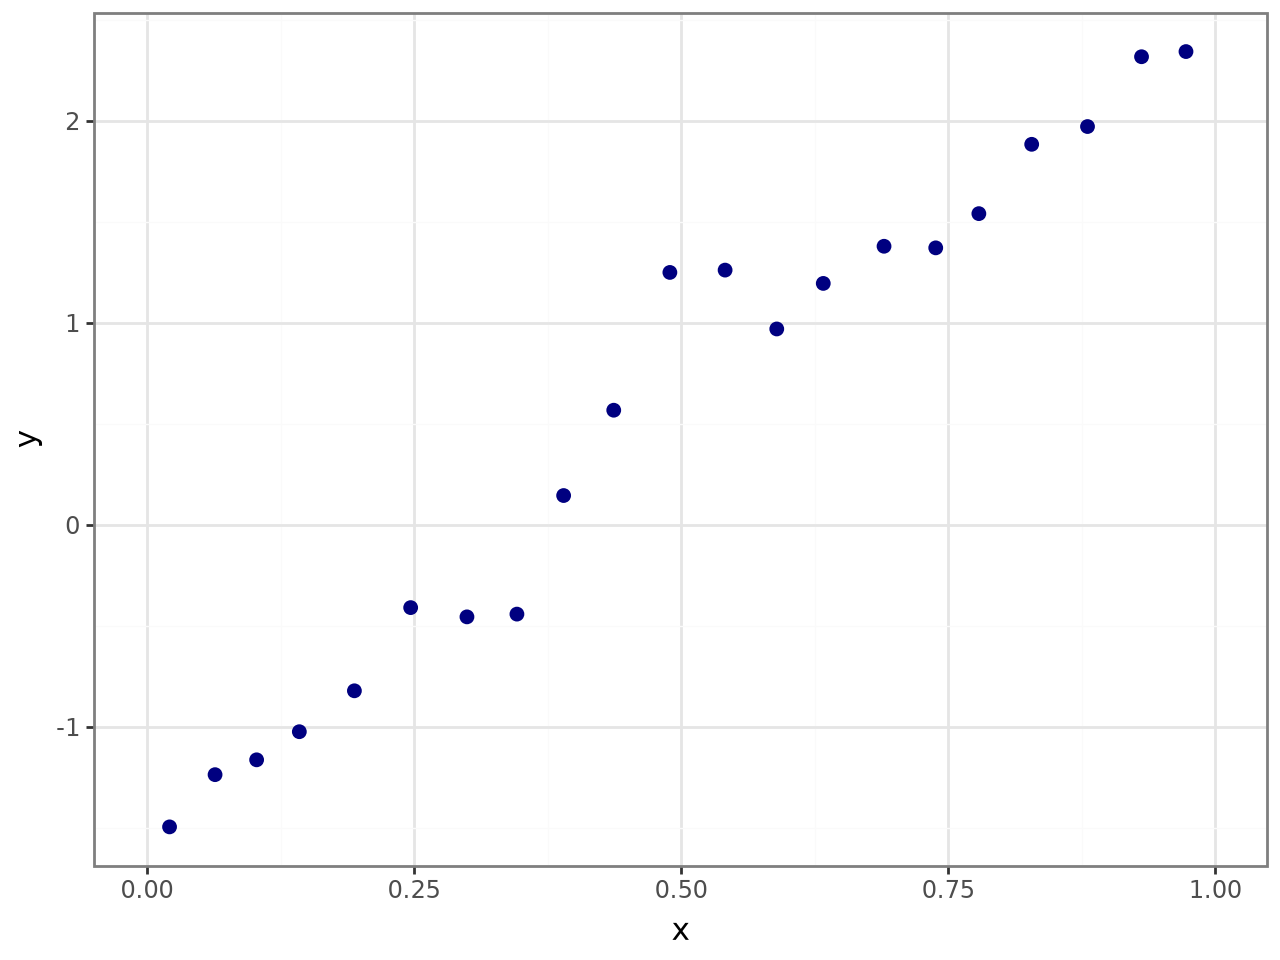

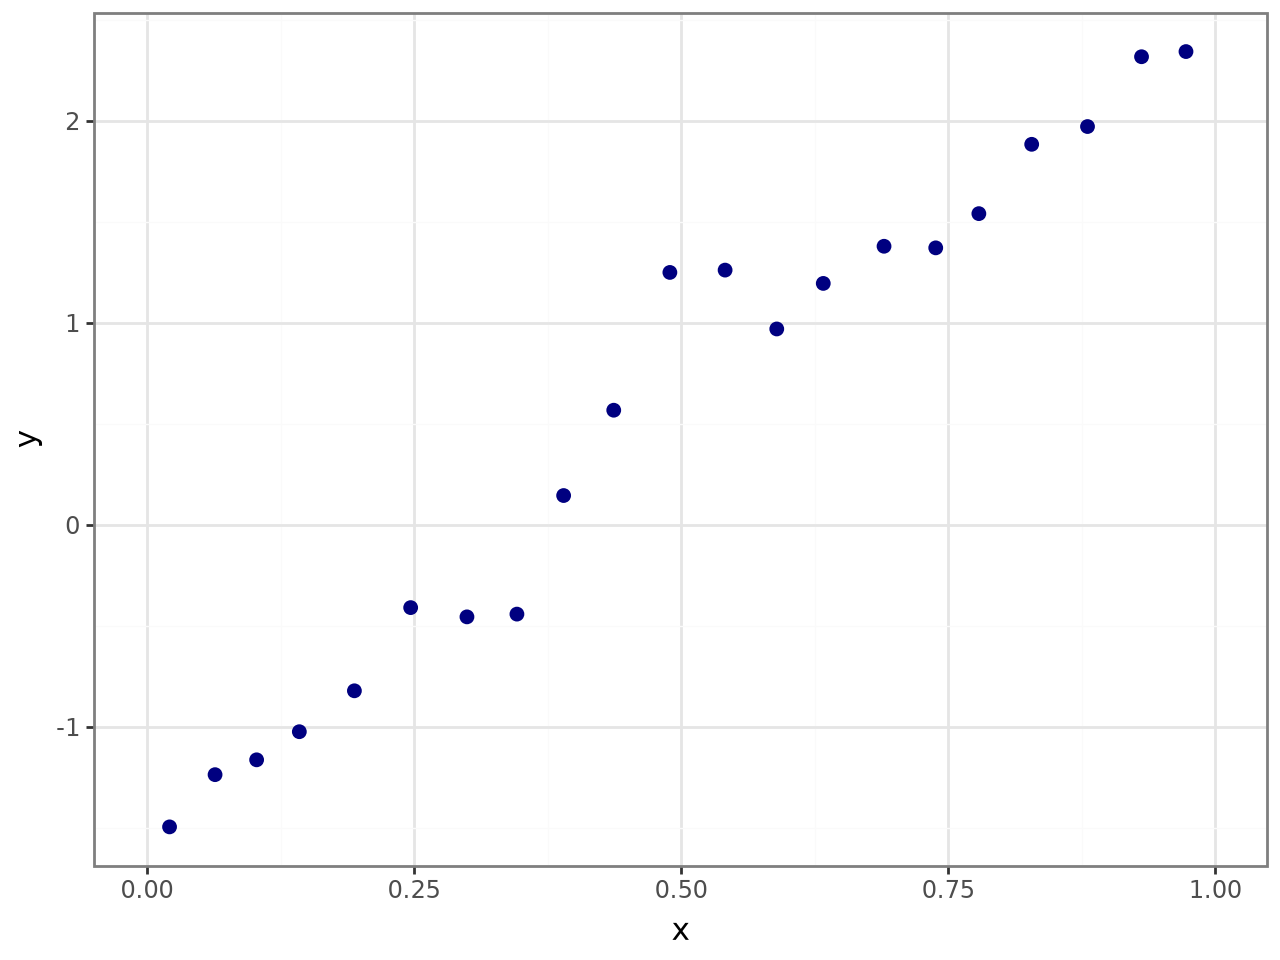

In [4]:
# Default syntax
est = binsreg('y', 'x', 'w', data=data, noplot=False)
est.bins_plot

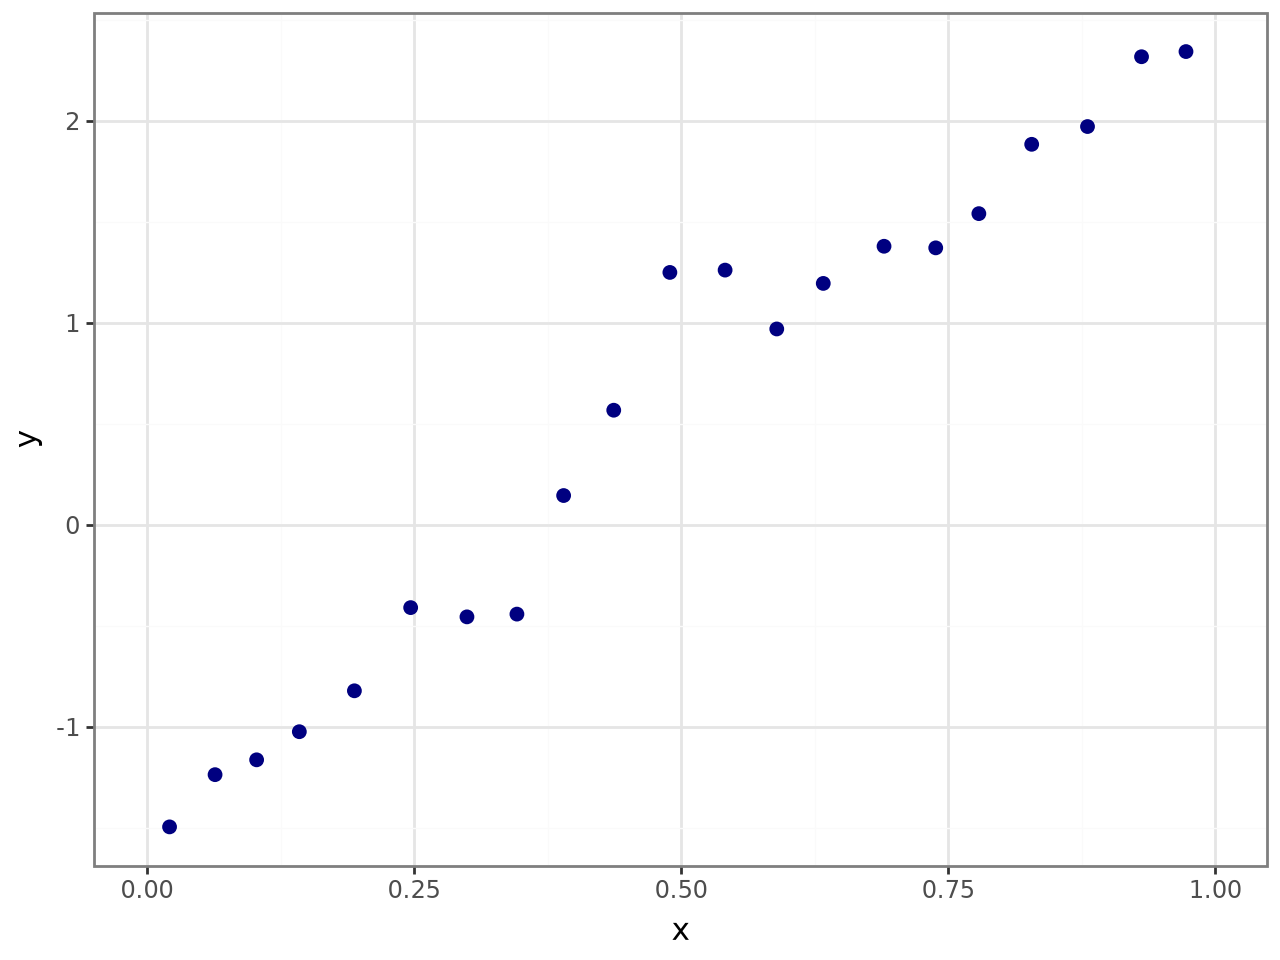

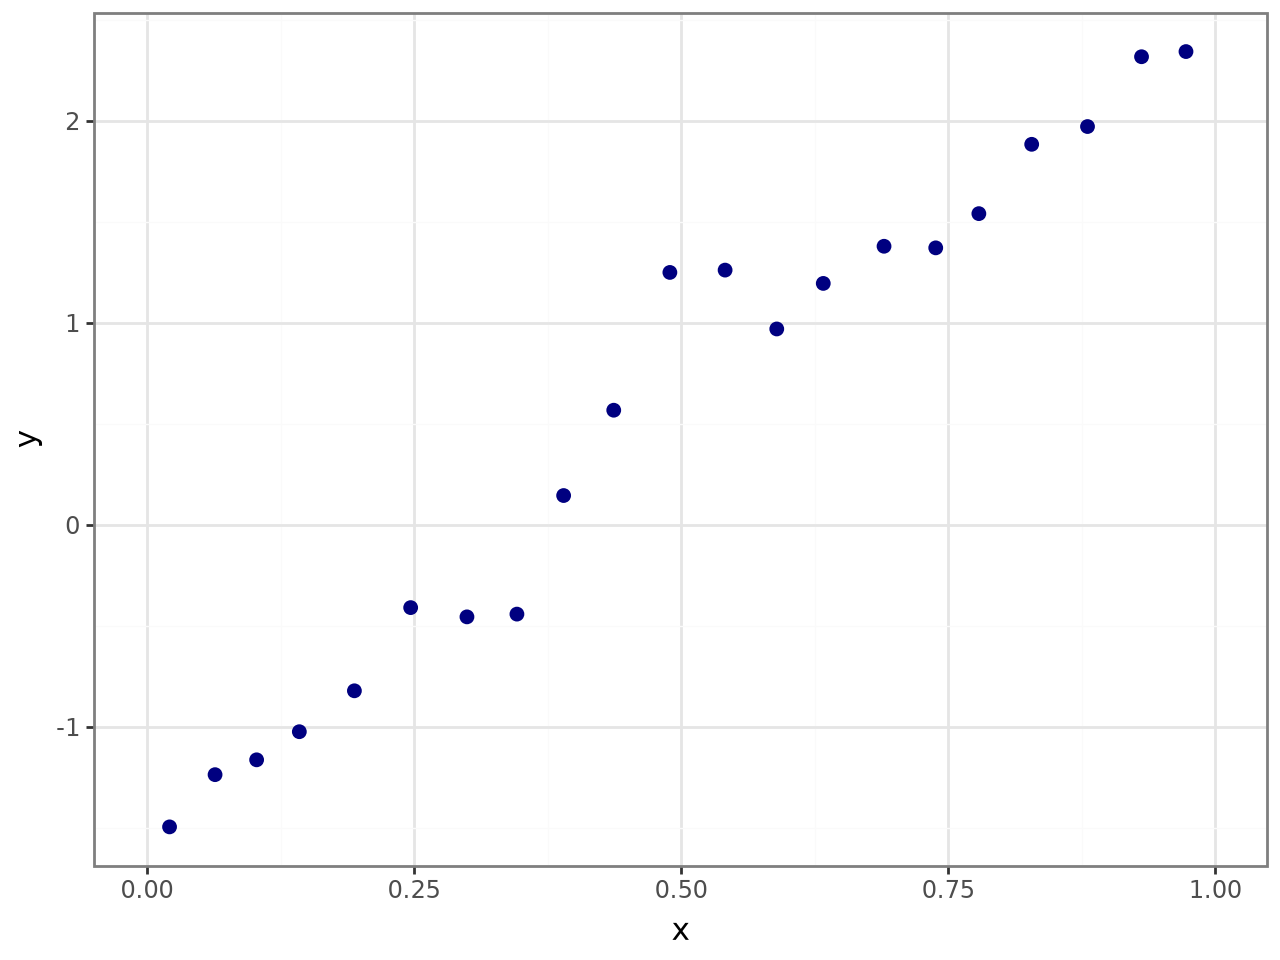

In [5]:
# Alternative: Specify y, x, w variables directly (without specifying a data frame)
y = data.y
x = data.x
w = data.w
est = binsreg(y, x, w)
est.bins_plot

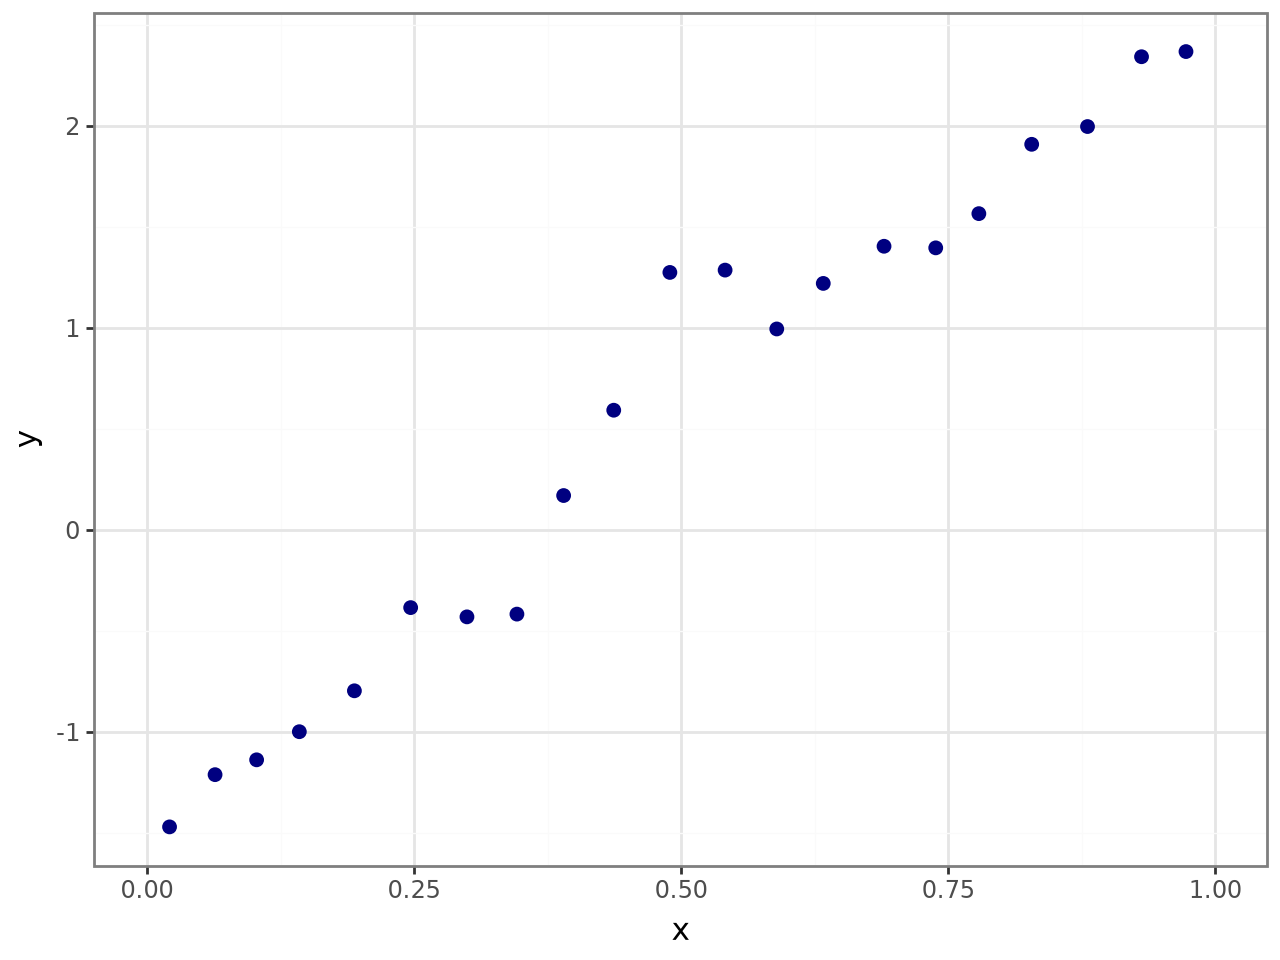

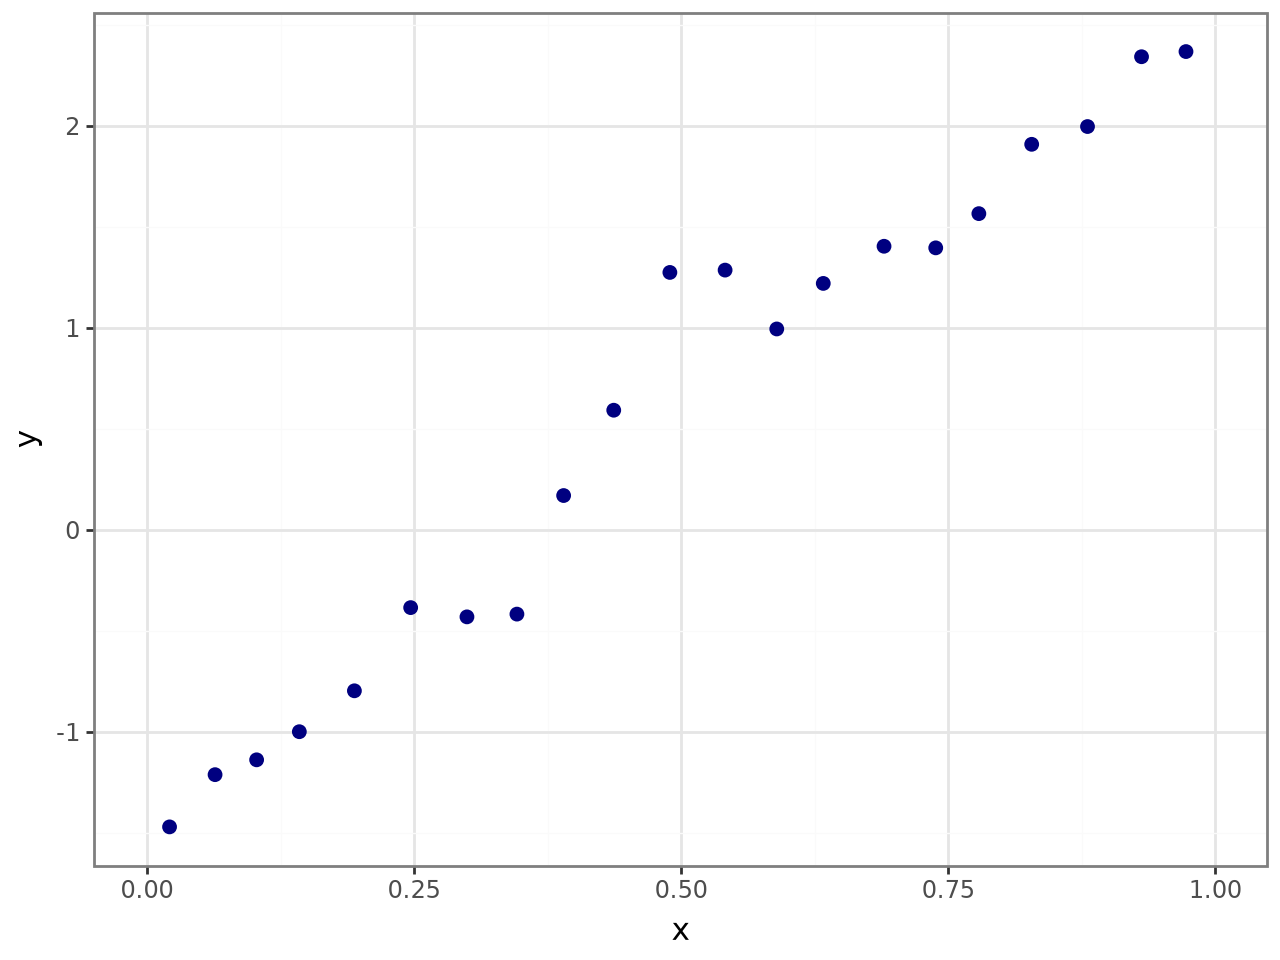

In [6]:
# Evaluate the estimated function at median of w rather than the mean
est = binsreg('y', 'x', 'w', at="median", data=data)
est.bins_plot

Note: When additional covariates w are included, the polynomial fit may not always be close to the binscatter fit.


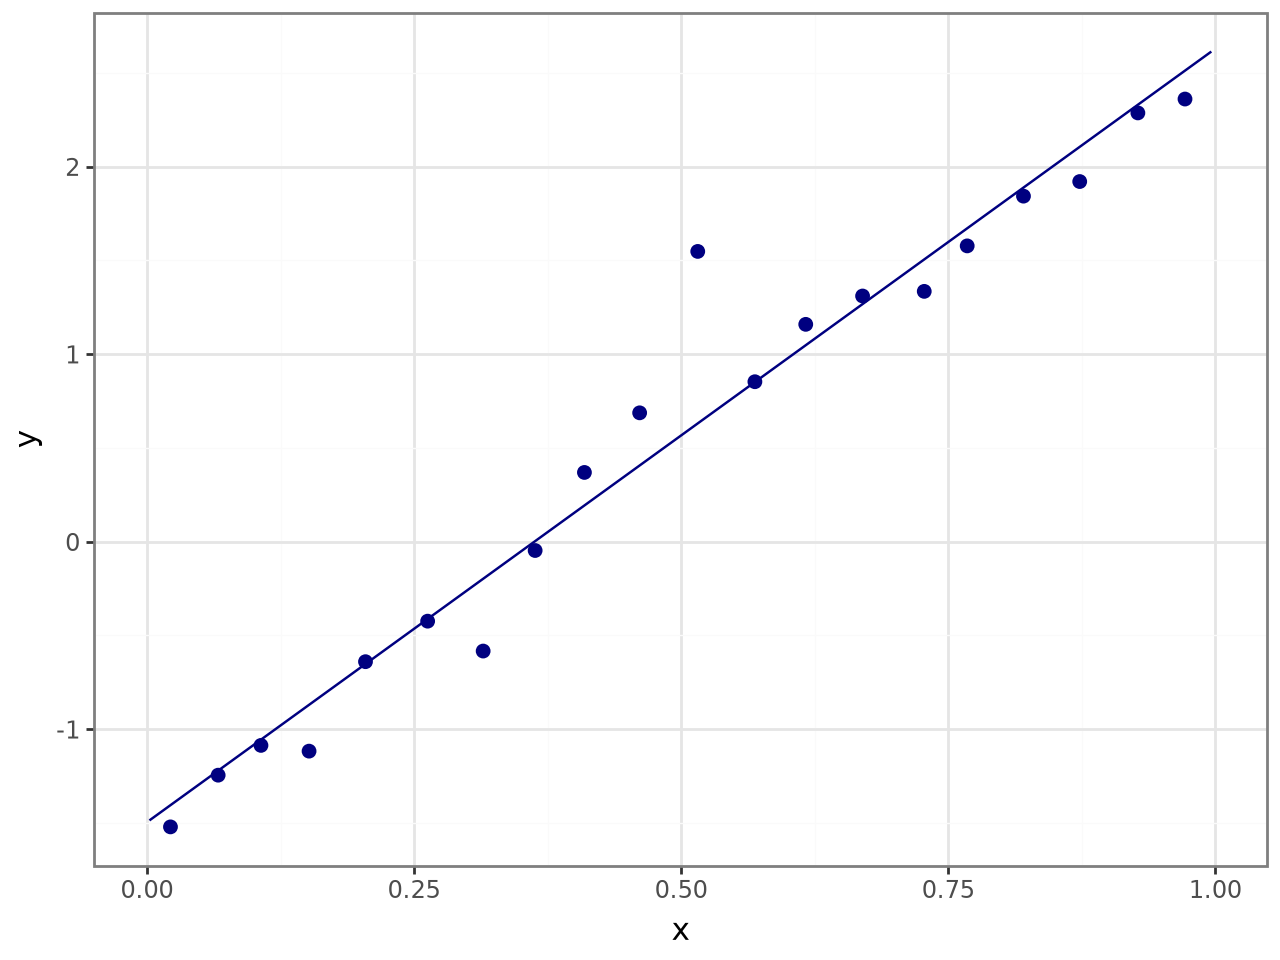

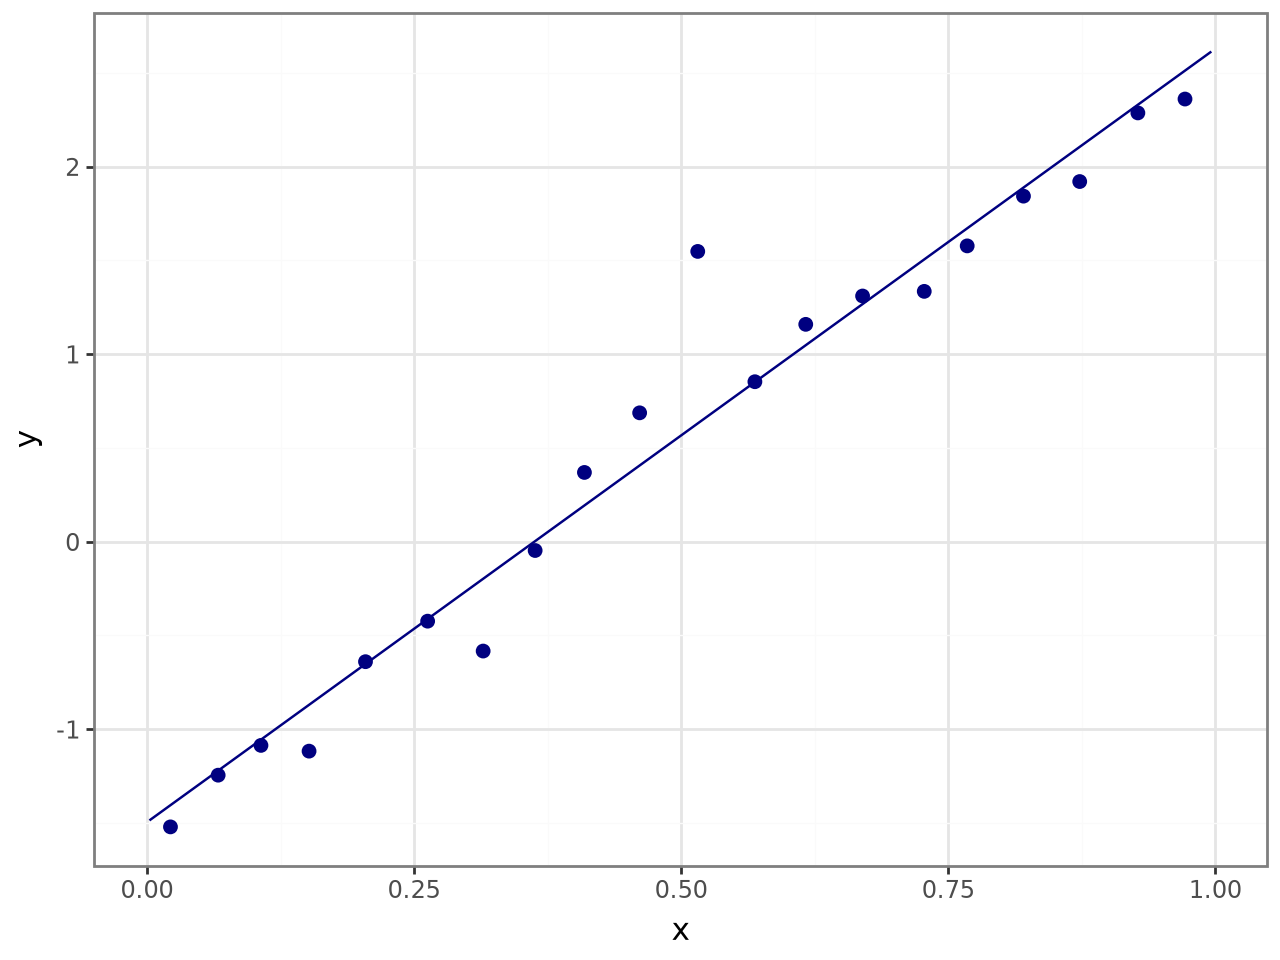

In [7]:
# Setting quantile-spaced bins to J=20, add a linear fit
est = binsreg('y', 'x', 'w', data=data, nbins=20, polyreg=1)
est.bins_plot

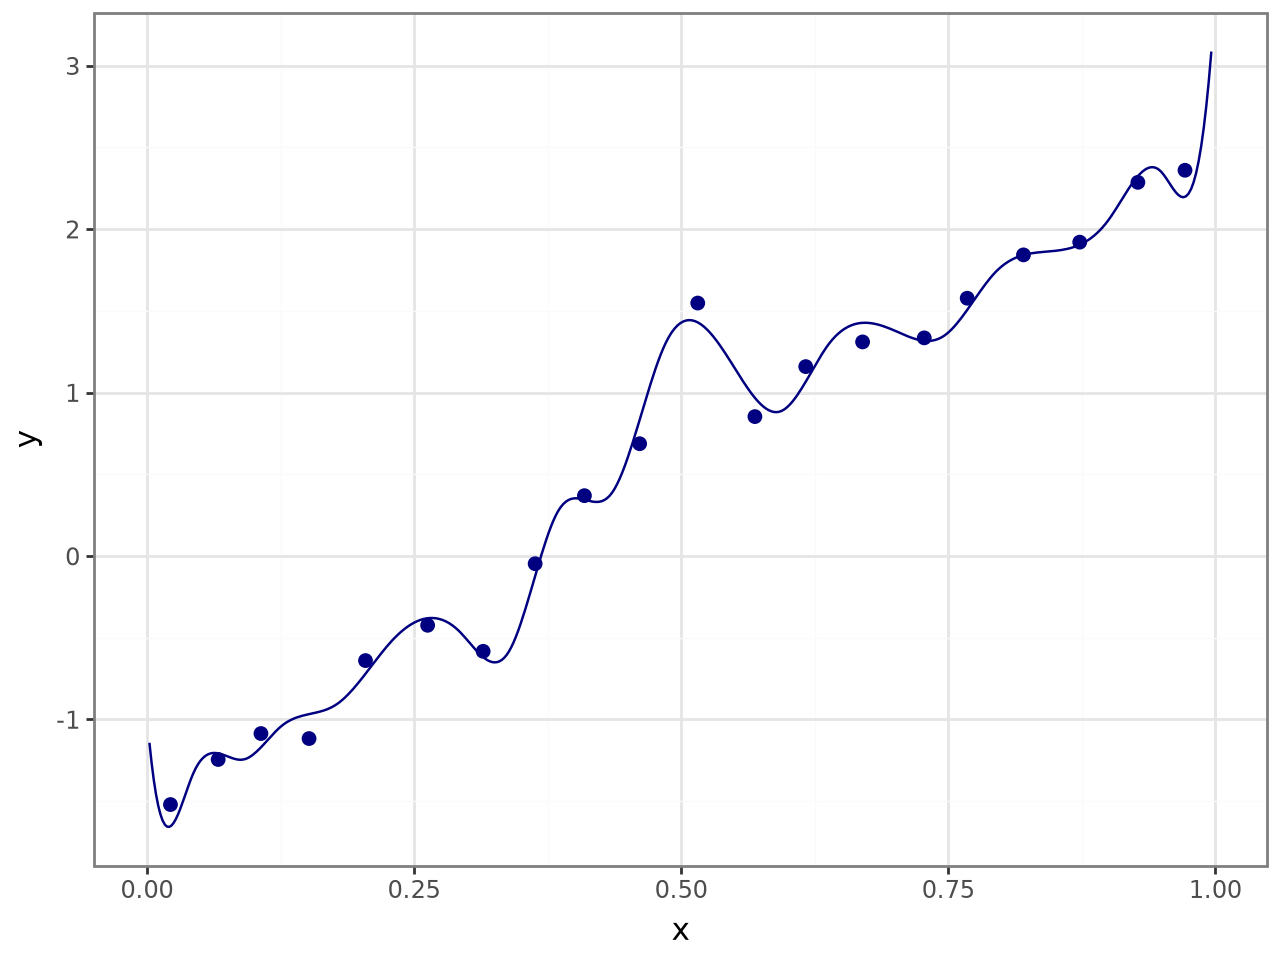

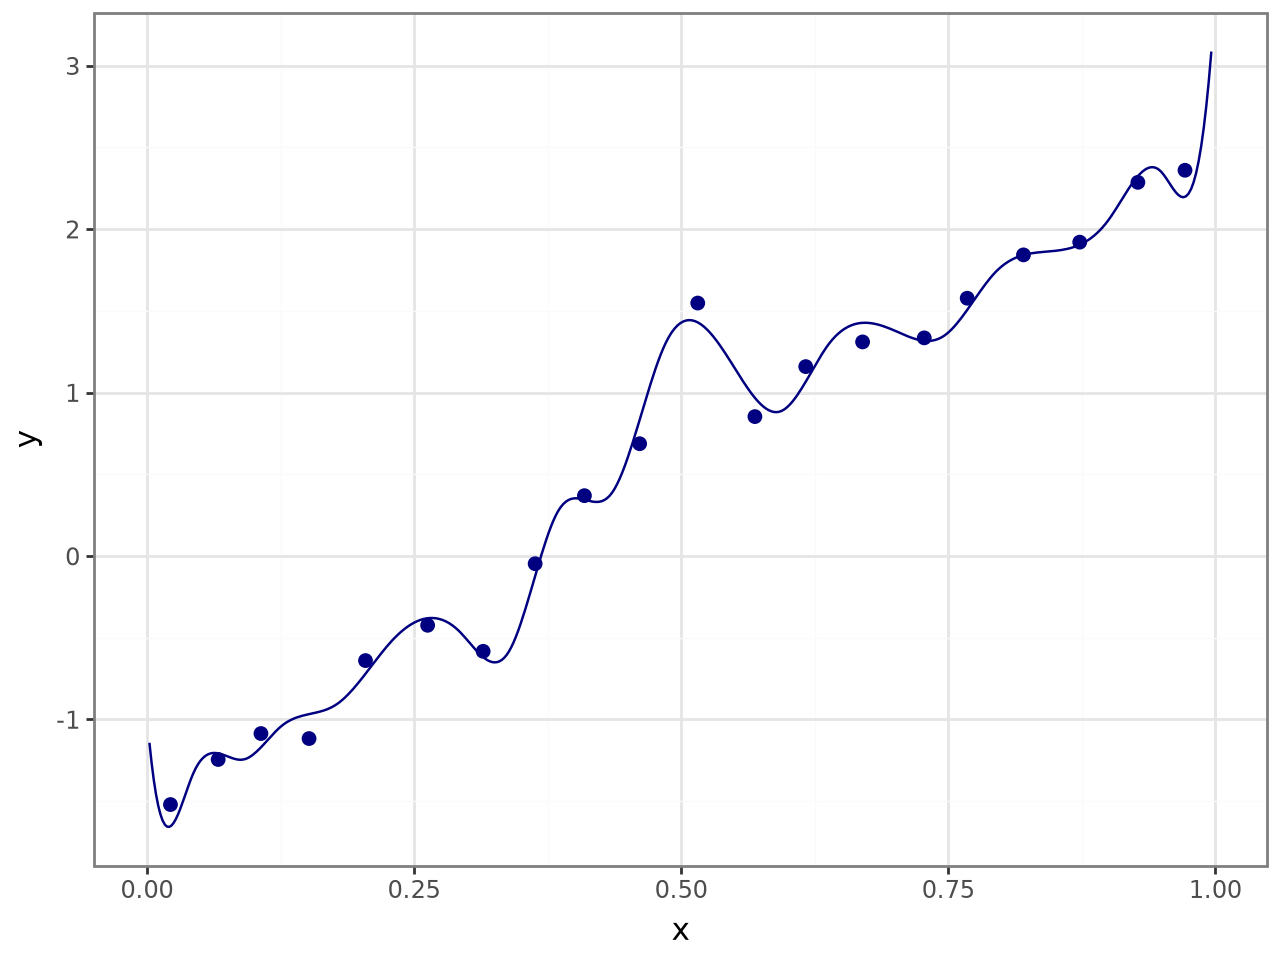

In [8]:
# Adding lines, ci, cb, polyreg
est = binsreg('y', 'x', 'w', data=data, nbins=20, line=(3,3))
est.bins_plot

C:\Users\zypub\Documents\github\my-projects\alphaecon\.venv\Lib\site-packages\binsreg\binsreg.py:670: UserWarning: Confidence intervals/bands are valid when nbins is much larger than the IMSE-optimal choice. Compare your choice with the IMSE-optimal one obtained by binsregselect().


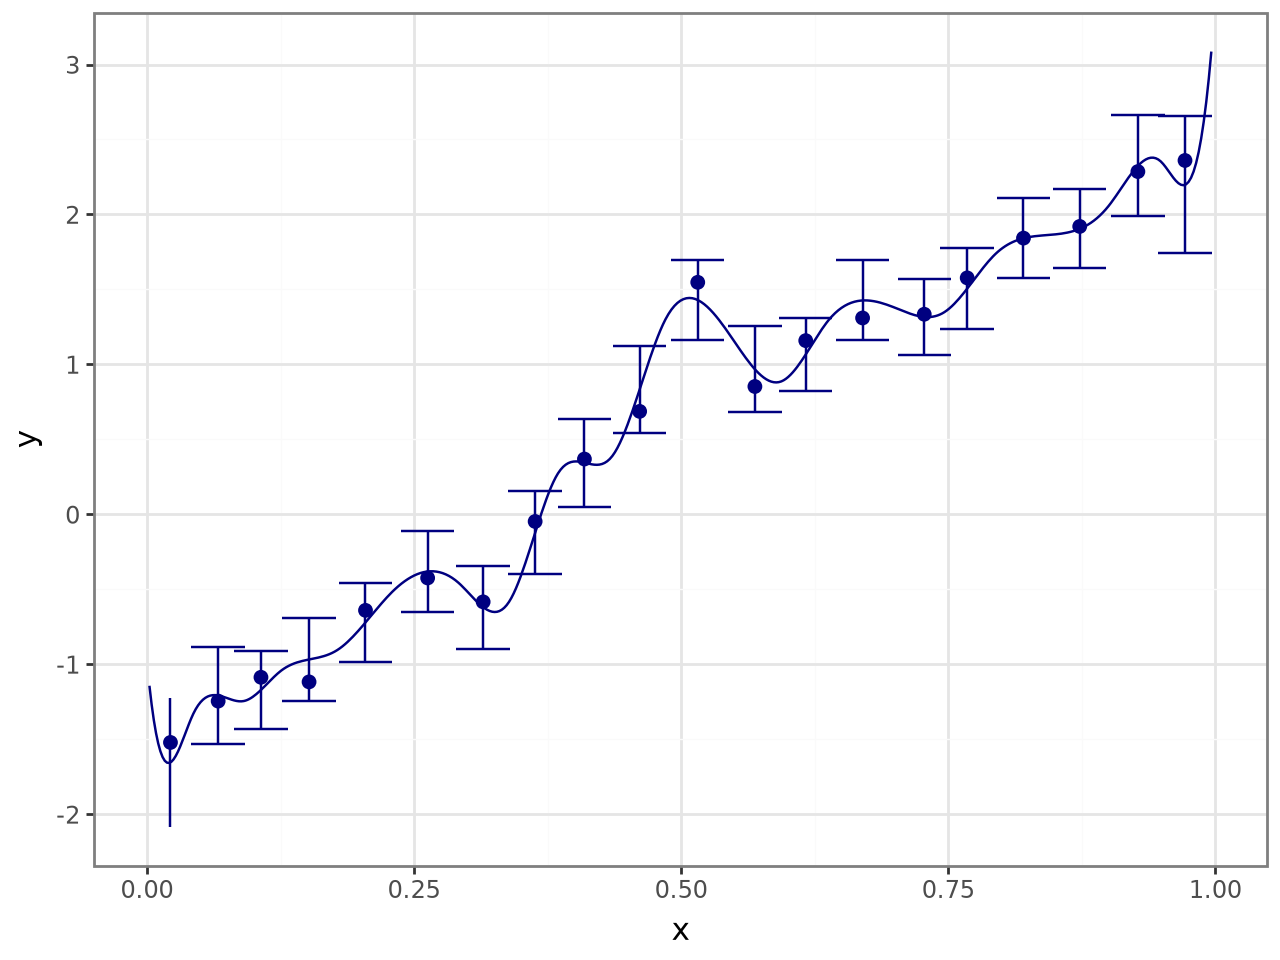

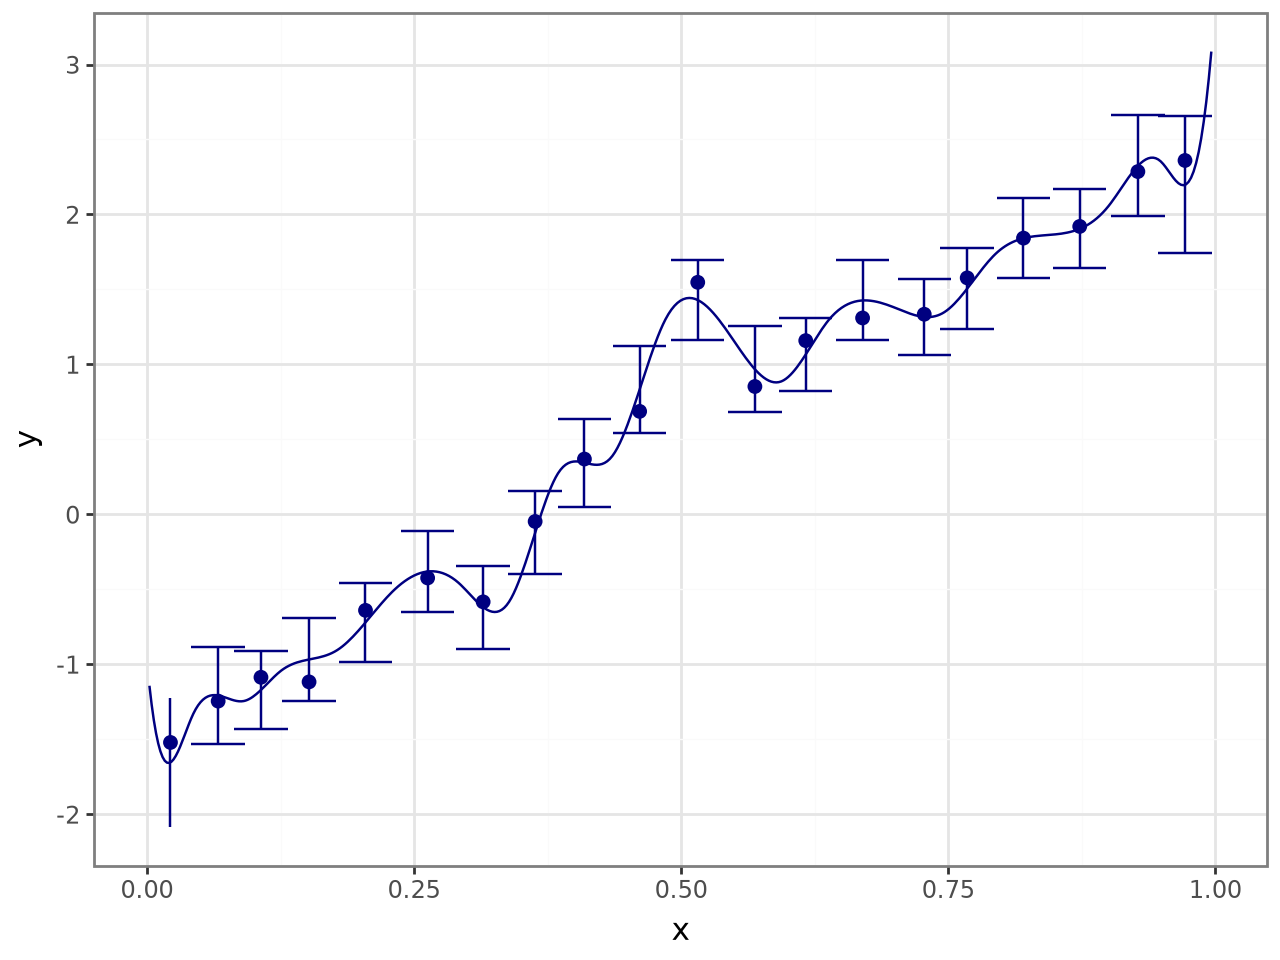

In [9]:
est = binsreg('y', 'x', 'w', data=data, nbins=20, line=(3,3), ci=(3,3))
est.bins_plot

C:\Users\zypub\Documents\github\my-projects\alphaecon\.venv\Lib\site-packages\binsreg\binsreg.py:670: UserWarning: Confidence intervals/bands are valid when nbins is much larger than the IMSE-optimal choice. Compare your choice with the IMSE-optimal one obtained by binsregselect().


Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.


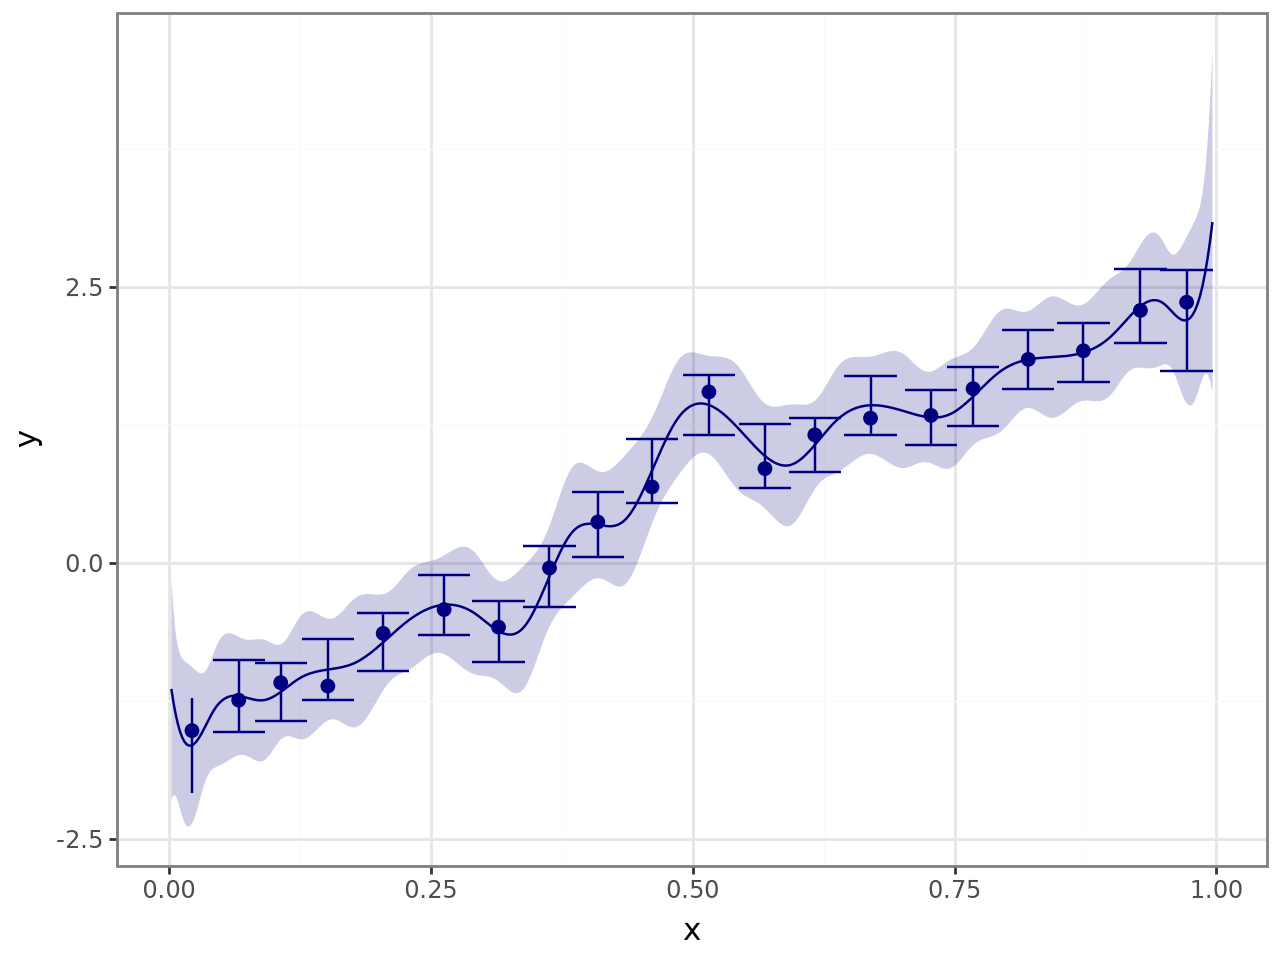

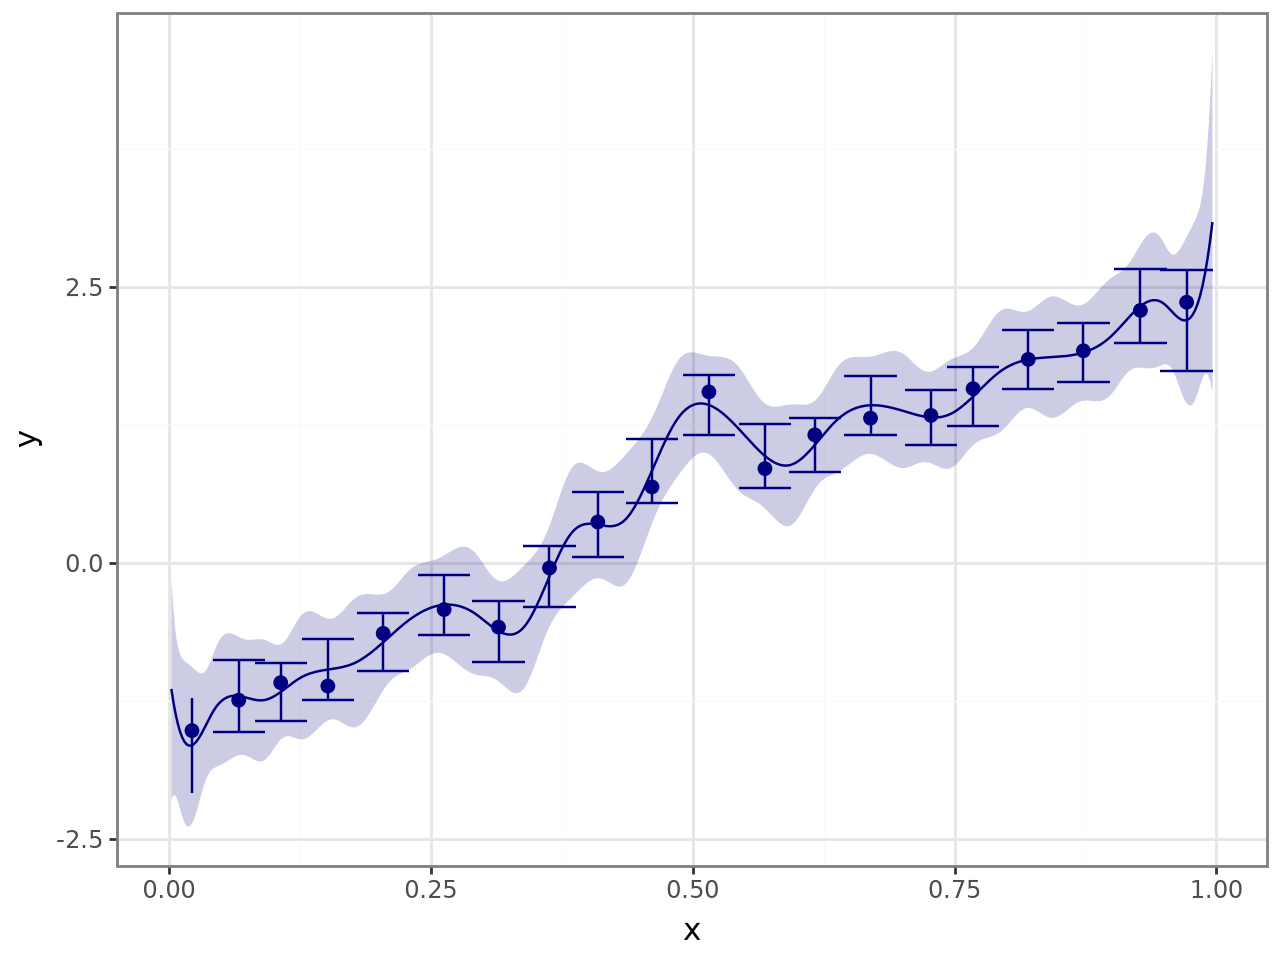

In [10]:
est = binsreg('y', 'x', 'w', data=data, nbins=20, line=(3,3), ci=(3,3), cb=(3,3))
est.bins_plot

C:\Users\zypub\Documents\github\my-projects\alphaecon\.venv\Lib\site-packages\binsreg\binsreg.py:670: UserWarning: Confidence intervals/bands are valid when nbins is much larger than the IMSE-optimal choice. Compare your choice with the IMSE-optimal one obtained by binsregselect().


Note: When additional covariates w are included, the polynomial fit may not always be close to the binscatter fit.
Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.


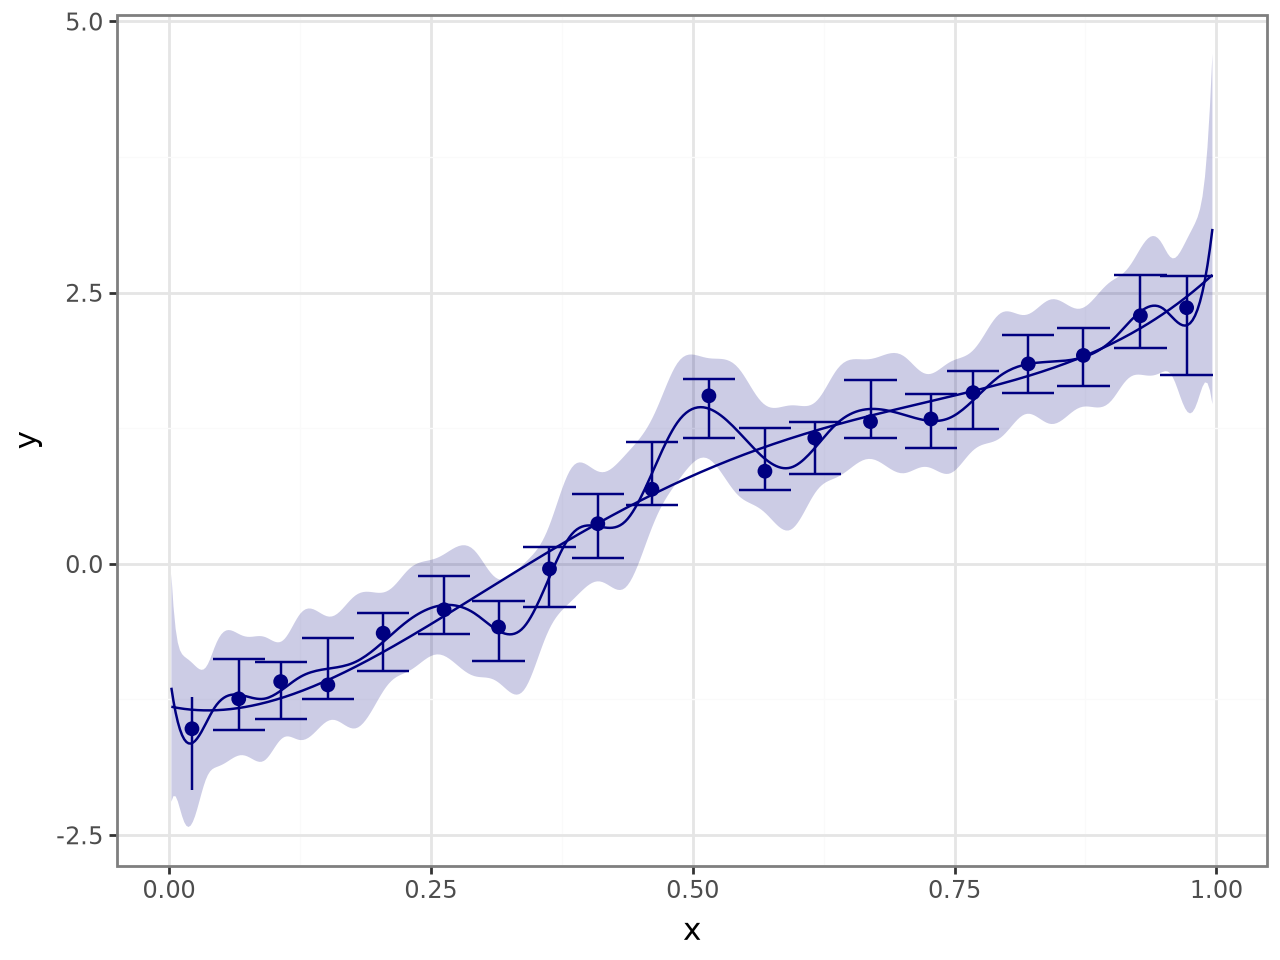

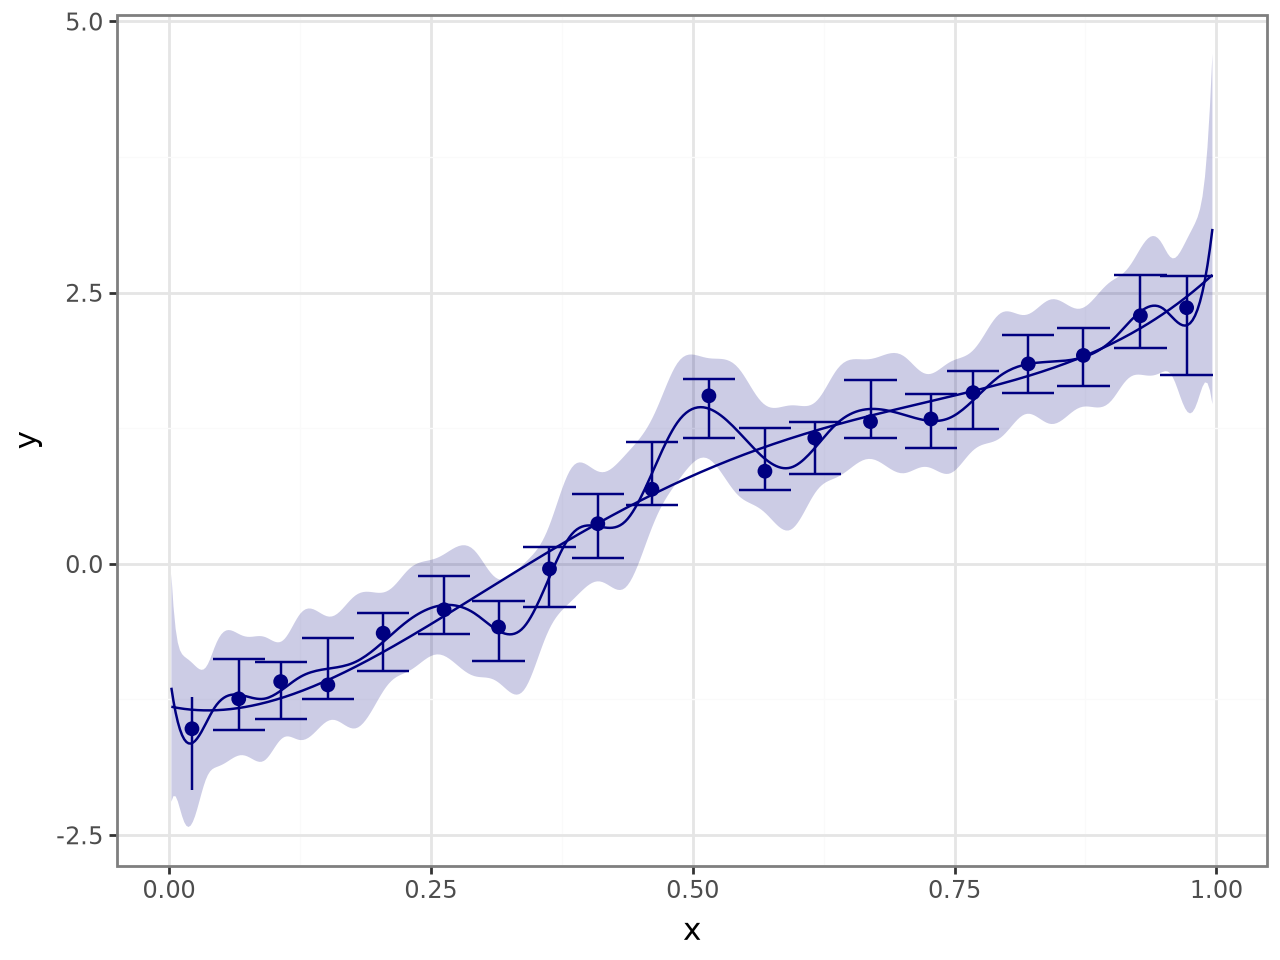

In [11]:
est = binsreg('y', 'x', 'w', data=data, nbins=20, line=(3,3), ci=(3,3), cb=(3,3), polyreg=4)
est.bins_plot

Note: When additional covariates w are included, the polynomial fit may not always be close to the binscatter fit.
Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.


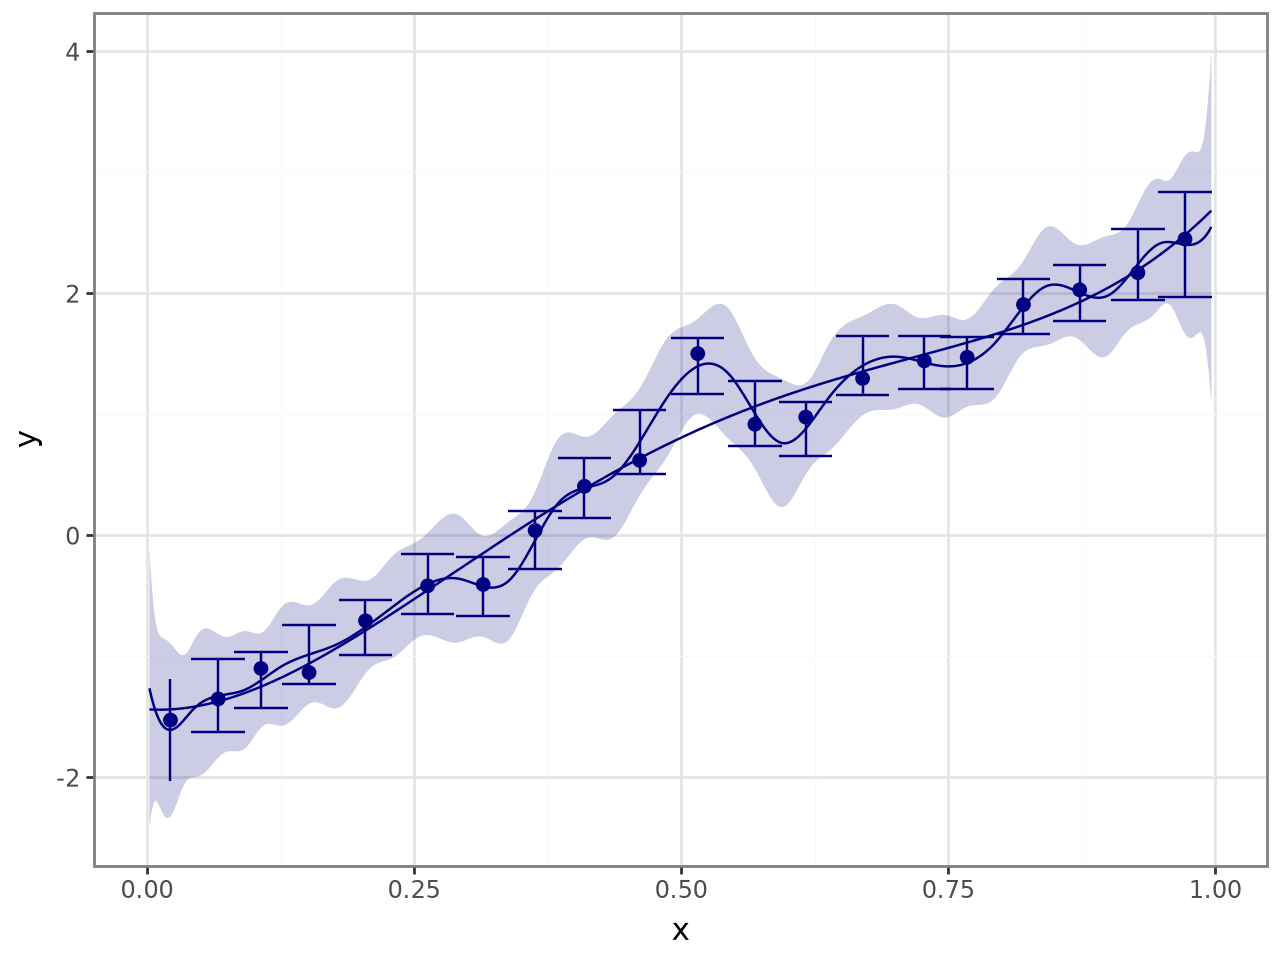

In [12]:
#  VCE option, ggplot object modification
est = binsreg('y', 'x', ['w', 't'], data=data, dots=(0,0), line=(3,3), ci=(3,3),
               cb=(3,3), polyreg=4, vce='HC1', cluster=data.id)

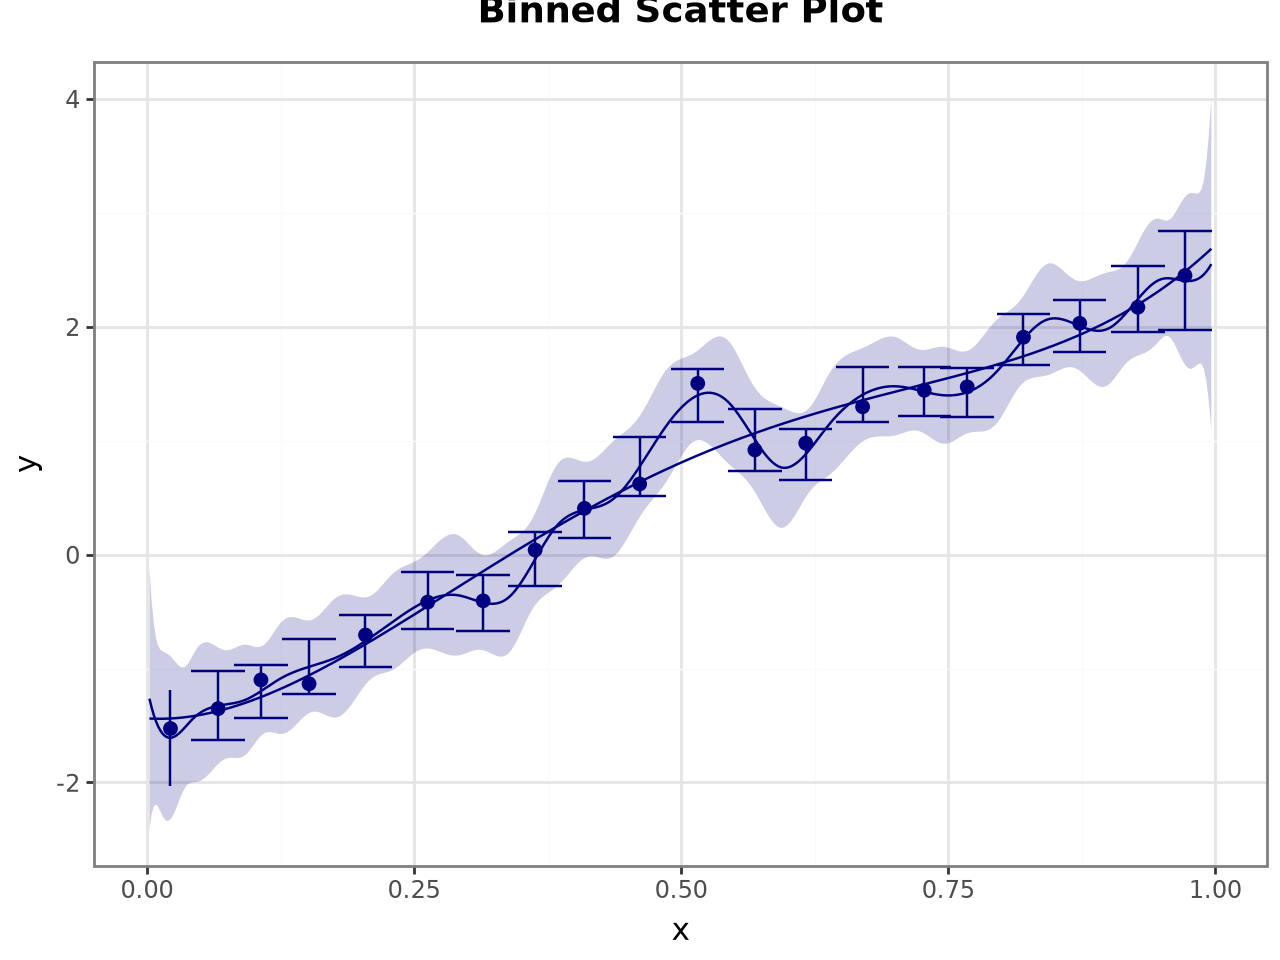

In [13]:
# Modify other ggplot features
est.bins_plot + ggtitle('Binned Scatter Plot') + theme(plot_title=element_text(hjust=0.5, vjust=0.5, face='bold'))

Note: When additional covariates w are included, the polynomial fit may not always be close to the binscatter fit.
Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.


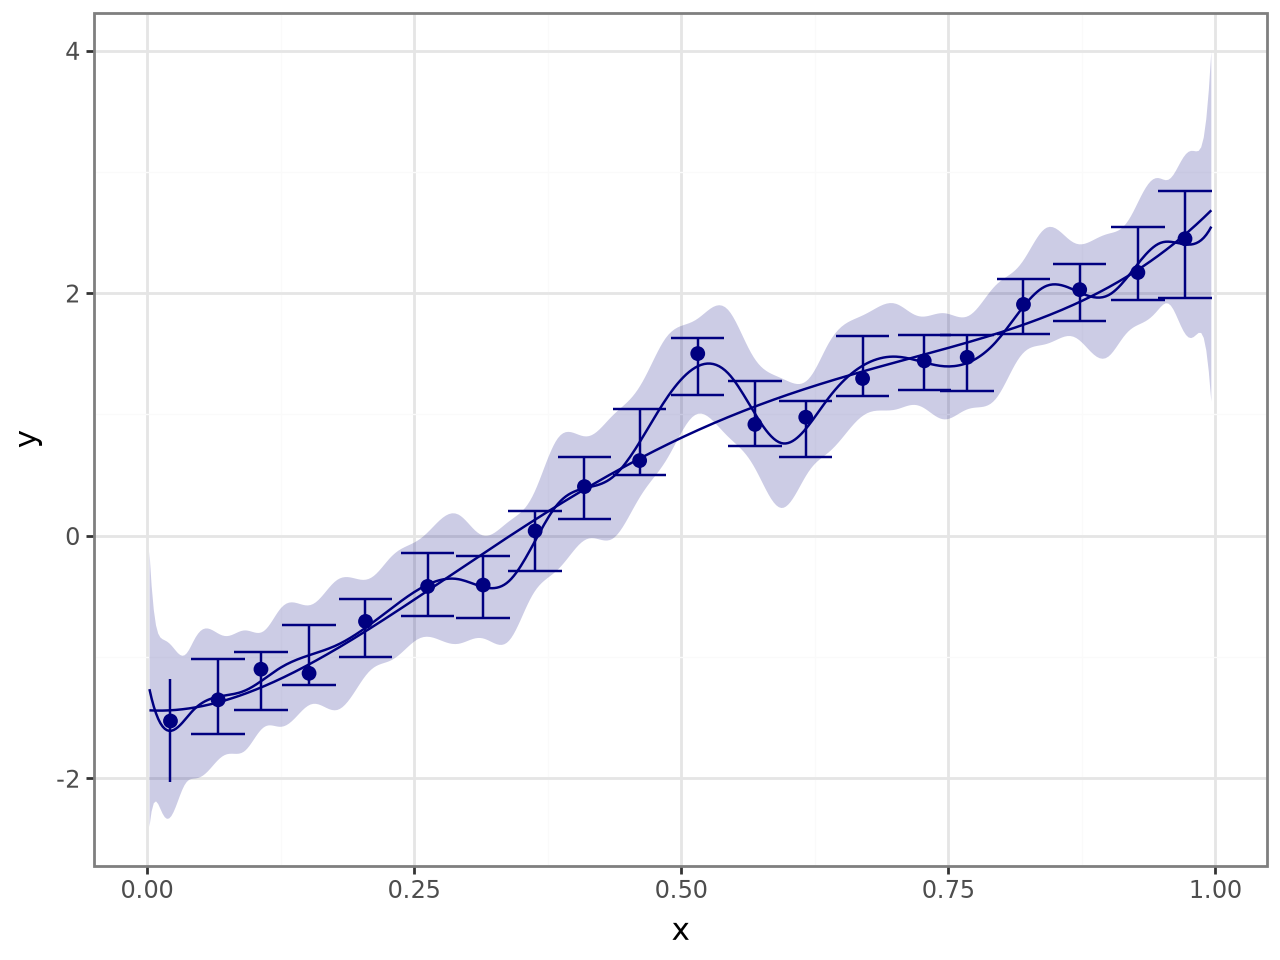

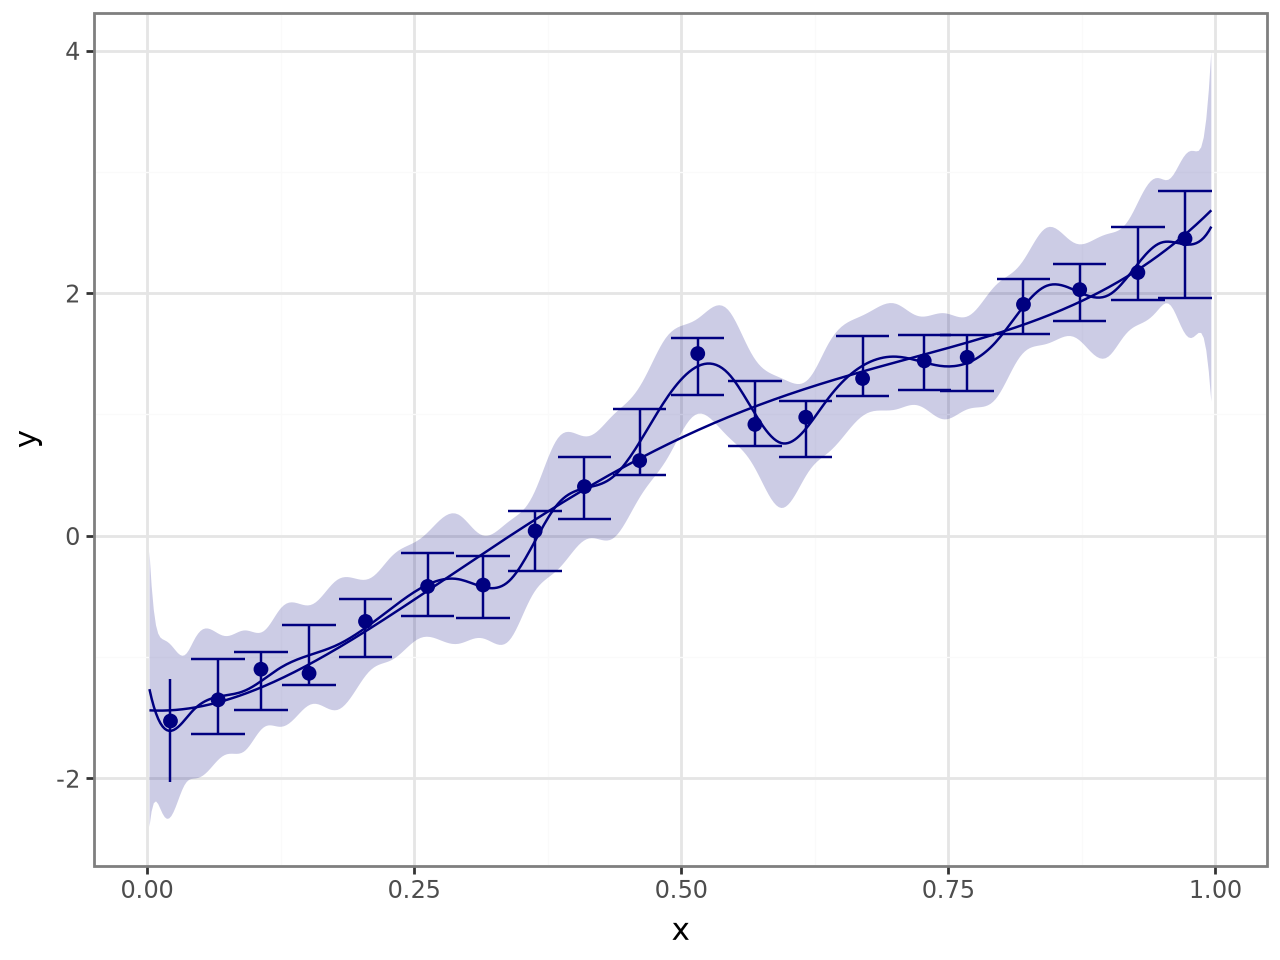

In [14]:
# CI and CB: alternative formula for standard errors (nonparametric component only)
est = binsreg('y', 'x', ['w', 't'], data=data, dots=(0,0), line=(3,3), ci=(3,3),
               cb=(3,3), polyreg=4, vce="HC1", cluster=data.id, asyvar=True)
est.bins_plot

Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.
Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.


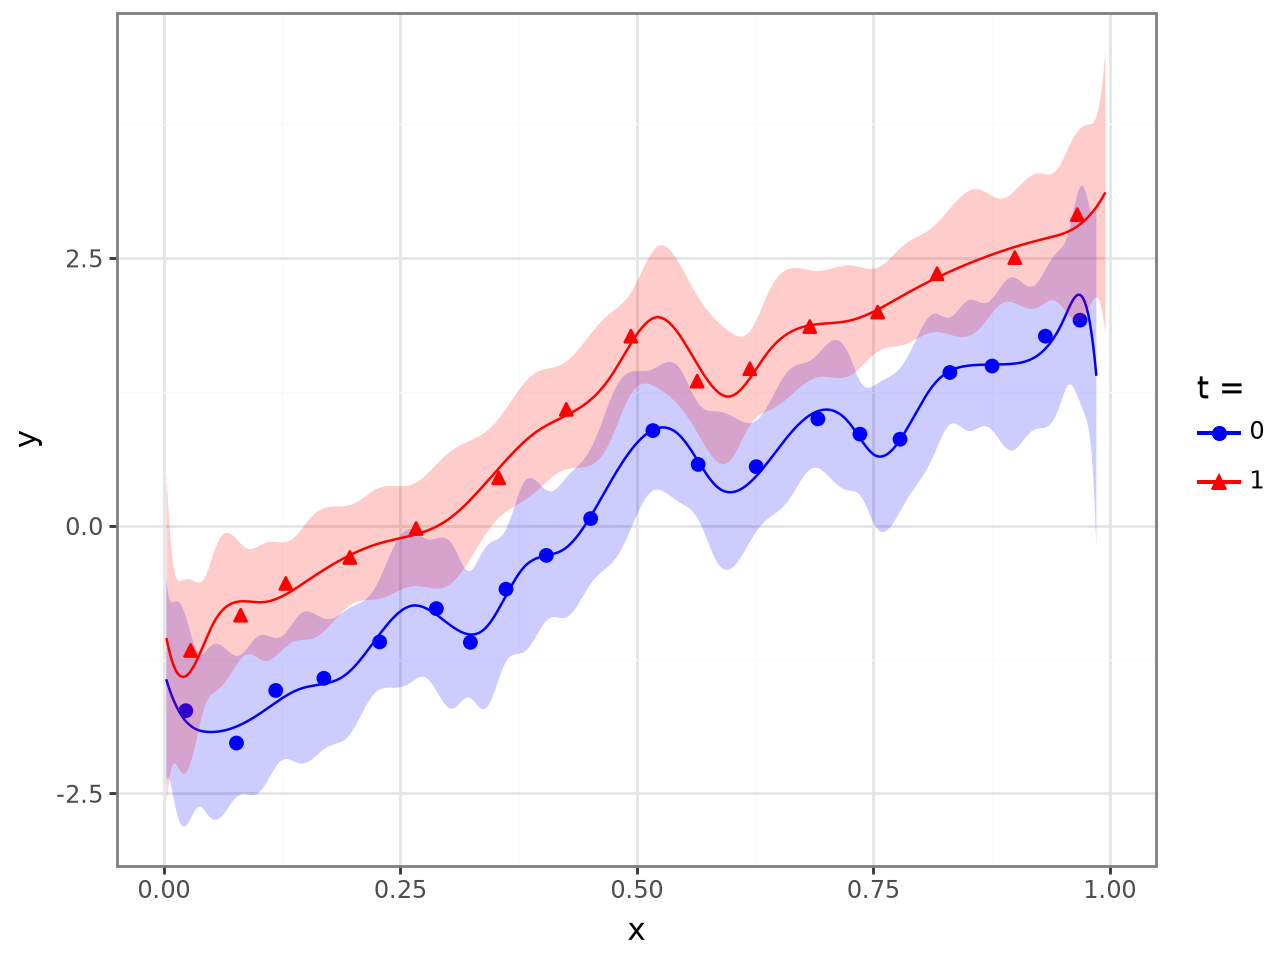

In [15]:
# Comparison by groups
est = binsreg('y', 'x', 'w', data=data, by='t', line=(3,3), cb=(3,3),
               bycolors=("blue", "red"), bysymbols=('o','^'))

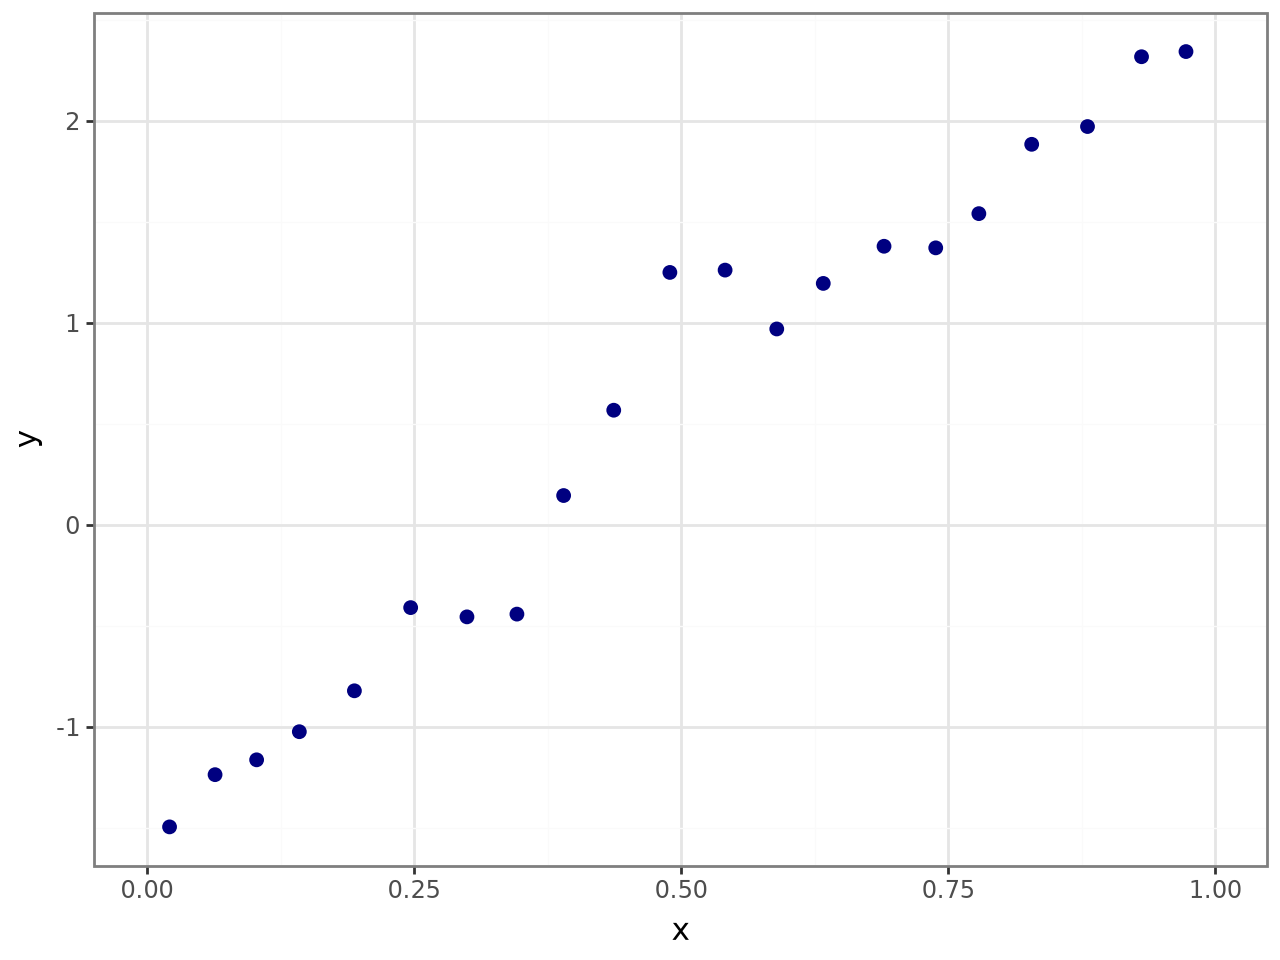

In [16]:
# Shut down all mass point checks to speed computation
est = binsreg('y', 'x', 'w', data=data, masspoints="off")

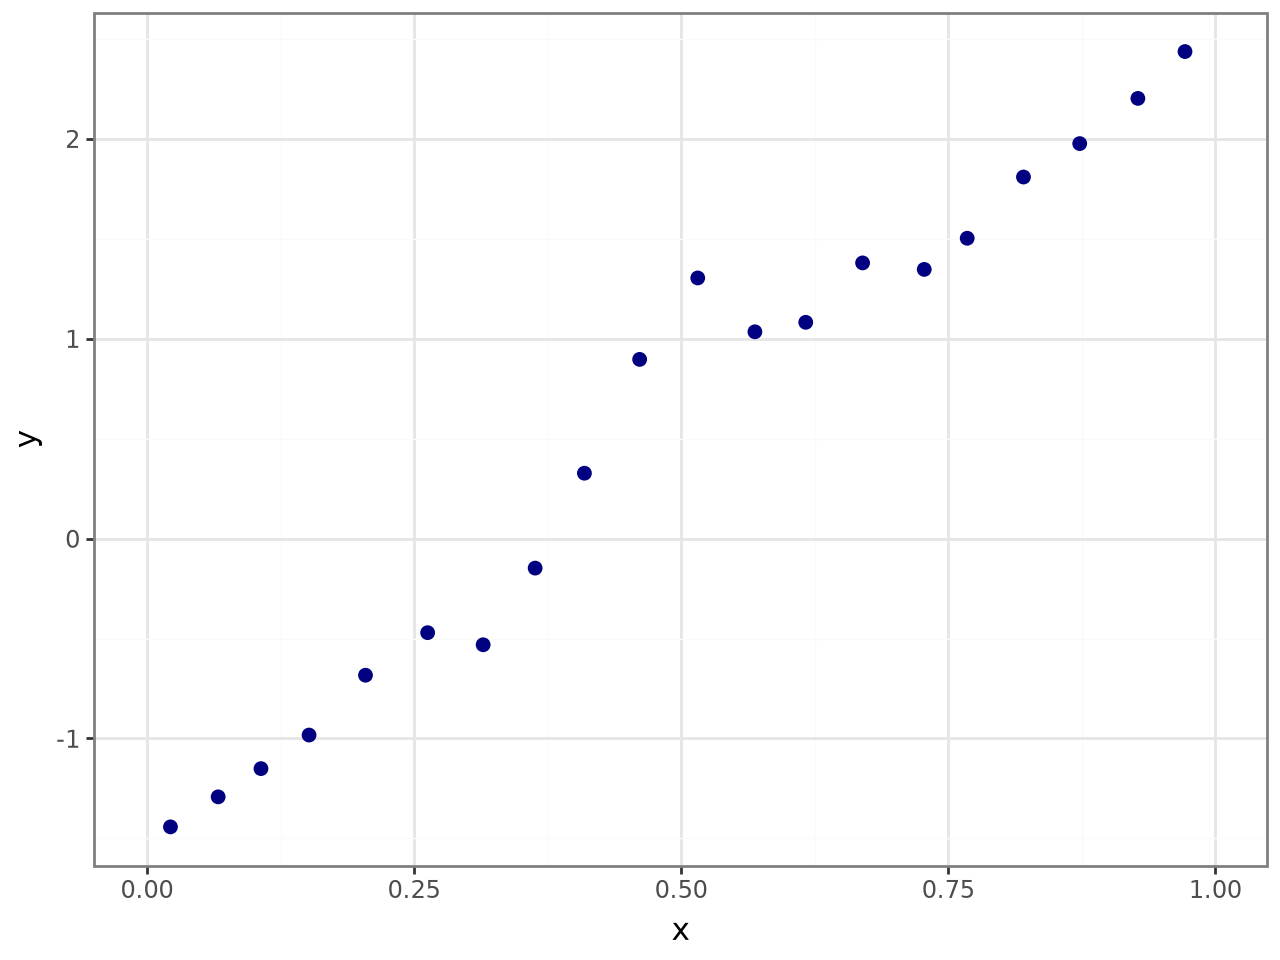

In [17]:
# Select the degree p and smoothness given the number of bins J
# Note: The selected p and s are used for point estimation;
#       p+1 and s+1 are used for confidence intervals/bands
est = binsreg('y', 'x', 'w', data=data, pselect=(1,2,3,4), nbins=20)

# BINSQREG

# `binsqreg`

The `binsqreg` function in `Python/binsreg/src/binsreg/binsqreg.py` implements data-driven binscatter quantile regression with robust inference and plotting. It estimates conditional quantiles of `y` given `x`, optionally adjusting for controls `w`, and supports binscatter-style points, fitted lines, confidence intervals, confidence bands, subgroup analysis, and automatic bin selection.

## Overview

`binsqreg` is designed for:

- flexible quantile regression with binscatter-style partitioning
- plot construction with dots, fitted lines, confidence intervals, and uniform confidence bands
- covariate adjustment via `w`
- subgroup analysis via `by`
- heteroskedastic-robust and cluster-robust inference
- data-driven bin selection when `nbins` is not fixed by the user

It is the quantile-regression companion to `binsreg` and is commonly used alongside `binsregselect`, `binstest`, `binsglm`, and `binspwc`.

## Function signature

```python
binsqreg(
    y,
    x,
    w=None,
    data=None,
    at=None,
    quantile=0.5,
    deriv=0,
    dots=None,
    dotsgrid=0,
    dotsgridmean=True,
    line=None,
    linegrid=20,
    ci=None,
    cigrid=0,
    cigridmean=True,
    cb=None,
    cbgrid=20,
    polyreg=None,
    polyreggrid=20,
    polyregcigrid=0,
    by=None,
    bycolors=None,
    bysymbols=None,
    bylpatterns=None,
    legendTitle=None,
    legendoff=False,
    nbins=None,
    binspos="qs",
    binsmethod="dpi",
    nbinsrot=None,
    samebinsby=False,
    randcut=None,
    pselect=None,
    sselect=None,
    nsims=500,
    simsgrid=20,
    simsseed=None,
    vce="nid",
    cluster=None,
    asyvar=False,
    level=95,
    noplot=False,
    dfcheck=(20, 30),
    masspoints="on",
    weights=None,
    subset=None,
    plotxrange=None,
    plotyrange=None,
    **optimize,
)
```

## Inputs and parameters

### Main data inputs

- `y`: outcome variable. Can be a vector or a column name when `data` is supplied.
- `x`: regressor of interest. Can be a vector or a column name when `data` is supplied.
- `w`: optional control variables. Can be a vector, matrix, or a list of column names when `data` is supplied.
- `data`: optional pandas DataFrame containing the variables used in the model.
- `quantile`: quantile to estimate, strictly between 0 and 1.
- `at`: value(s) of `w` at which the estimated function is evaluated. Common settings are `"mean"`, `"median"`, or `"zero"`.
- `deriv`: derivative order to estimate. `0` estimates the function itself.
- `weights`: optional observation weights.
- `subset`: optional subset selector for observations.

### Plotting controls

- `dots`: binscatter dots specification. Typical usage is `dots=(p, s)`, where `p` is the polynomial degree and `s` is the smoothness constraint. If `dots=True`, a default binscatter is used.
- `dotsgrid`: number of evaluation points per bin for plotting dots.
- `dotsgridmean`: whether to include the bin-mean evaluation point in the plotted dots.
- `line`: line overlay specification, used for a smoothed fitted line. The syntax is `line=(p, s)`, where `p` is the polynomial degree and `s` is the smoothness constraint.
- `linegrid`: grid resolution used for evaluating the line.
- `ci`: pointwise confidence interval specification.
- `cigrid`: grid resolution used for confidence interval construction.
- `cigridmean`: whether to include bin-mean confidence intervals.
- `cb`: uniform confidence band specification.
- `cbgrid`: grid resolution used for confidence band construction.
- `polyreg`: optional global polynomial regression to overlay.
- `polyreggrid`: grid resolution for the polynomial fit.
- `polyregcigrid`: grid resolution for polynomial confidence intervals.
- `noplot`: if `True`, suppresses plot creation while still returning plotting data.
- `plotxrange` and `plotyrange`: x- and y-axis ranges for the plot.

### Subgroup analysis and legend styling

- `by`: grouping variable for subgroup analysis. Separate quantile curves are estimated for each group.
- `bycolors`, `bysymbols`, `bylpatterns`: styling controls for subgroup series.
- `legendTitle`: title shown in the plot legend.
- `legendoff`: if `True`, hides the legend.
- `samebinsby`: if `True`, forces a common set of bins across groups.

### Binning and model selection

- `nbins`: number of bins. If omitted or set to `True`, the number of bins is selected automatically.
- `binspos`: binning position rule. Default is `"qs"` for quantile-spaced bins; `"es"` is also supported.
- `binsmethod`: selection method for bin count. Default is `"dpi"` (direct plug-in); `"rot"` is an alternative.
- `nbinsrot`: initial number of bins used in constructing the DPI selector.
- `pselect`, `sselect`: candidate values used when selecting the polynomial degree and smoothness constraints.
- `randcut`: random subsample cutoff used in selection procedures for large samples.

### Inference and robustness

- `nsims`: number of simulations used for confidence band construction.
- `simsgrid`: grid resolution used in the supremum approximation for confidence bands.
- `simsseed`: random seed for reproducible simulations.
- `vce`: variance estimator. The default is `"nid"`.
- `cluster`: cluster ID used to compute cluster-robust standard errors.
- `asyvar`: if `True`, ignores uncertainty from control variables when computing the standard error of the nonparametric component.
- `level`: nominal confidence level for intervals/bands, expressed as a percentage.
- `dfcheck`: minimum effective sample size checks used to guard against overfitting or weak identification.
- `masspoints`: rule for handling repeated values (mass points) in `x`.

### Optimizer options

- `**optimize`: optional arguments passed to the `statsmodels` QuantReg optimizer.

## Return value

The function returns:

- `bins_plot`: a `ggplot` object suitable for display or saving.
- `data_plot`: a nested list of plotting datasets, one per subgroup if `by` is used.

The plotting data may include DataFrames for:

- `dots`: fitted dot estimates
- `line`: fitted line estimates
- `ci`: pointwise confidence intervals
- `cb`: uniform confidence band
- `poly`: global polynomial regression fit
- `polyci`: polynomial regression confidence intervals
- `data_bin`: binning structure summary
- `imse_v_rot`, `imse_b_rot`, `imse_v_dpi`, `imse_b_dpi`: IMSE selection constants
- `cval_by`: critical values for confidence bands by group
- `options`: option metadata and sample-size diagnostics

## Implementation notes

The function:

1. extracts variables from `data` when column names are supplied
2. reshapes and filters inputs, including `subset` handling and missing-value removal
3. determines subgroup structure and plotting defaults
4. validates the requested binning, polynomial, and inference settings
5. selects bins and polynomial degrees when needed
6. computes quantile-regression-based binscatter estimates and associated uncertainty
7. returns plotting objects and diagnostic data

If `nbins` is not specified, `binsregselect` is used to choose the binning in a data-driven way.

## Example usage

```python
import numpy as np
from binsreg.binsqreg import binsqreg

x = np.random.uniform(size=500)
y = np.sin(x) + np.random.normal(size=500)

out = binsqreg(y, x, quantile=0.5)
print(out)
```

A more complete example with controls and subgroup analysis:

```python
import pandas as pd
from binsreg.binsqreg import binsqreg

df = pd.DataFrame({
    "y": [0.5, 1.2, 2.0, 3.1, 4.0, 5.5],
    "x": [0.1, 0.4, 0.8, 1.2, 1.8, 2.5],
    "w1": [1.0, 0.5, 1.2, 0.8, 1.7, 2.0],
    "group": ["A", "A", "B", "B", "B", "A"],
})

result = binsqreg(
    y="y",
    x="x",
    w="w1",
    data=df,
    by="group",
    quantile=0.5,
    dots=(0, 0),
    line=(1, 1),
    ci=(1, 1),
    cb=(1, 1),
    nbins=10,
)
```

## Notes

- `quantile` must be strictly between 0 and 1.
- `samebinsby=True` forces a common binning structure across subgroups.
- If `data` is supplied, strings can be used for `x`, `y`, `w`, `by`, `cluster`, and `weights`.
- `vce` defaults to `"nid"` for quantile-regression inference.

## See also

- `binsregselect`: data-driven binscatter partition selection
- `binsreg`: least-squares binscatter estimation and plotting
- `binsglm`: binscatter generalized linear models
- `binstest`: binscatter-based hypothesis testing
- `binspwc`: pairwise comparisons of binscatter estimators

## References

The implementation follows the binscatter methods and testing framework developed in:

- Cattaneo, M. D., Crump, R. K., Farrell, M. H., and Feng, Y. (2024)
- Cattaneo, M. D., Crump, R. K., Farrell, M. H., and Feng, Y. (2026)


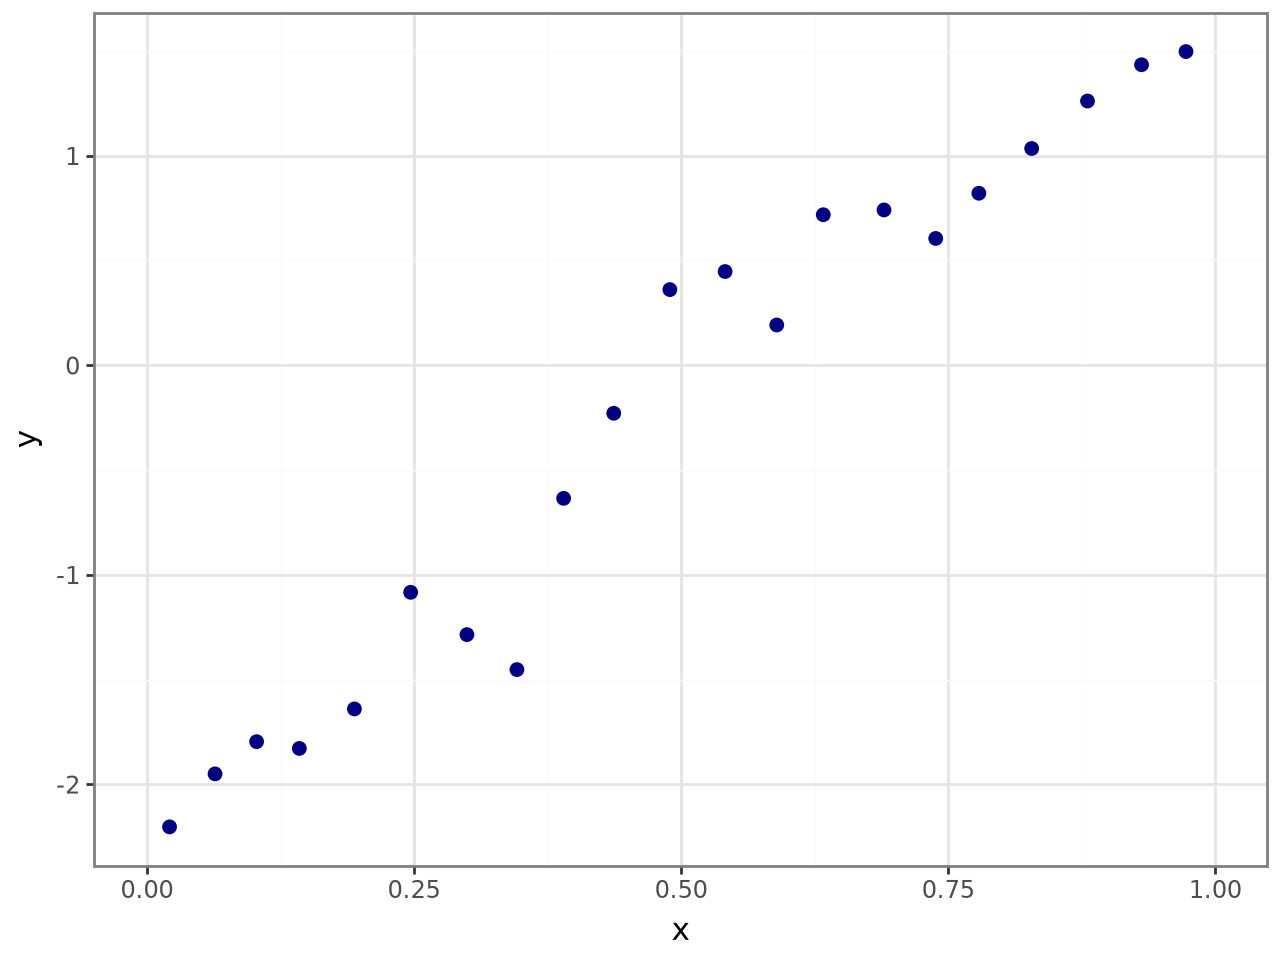

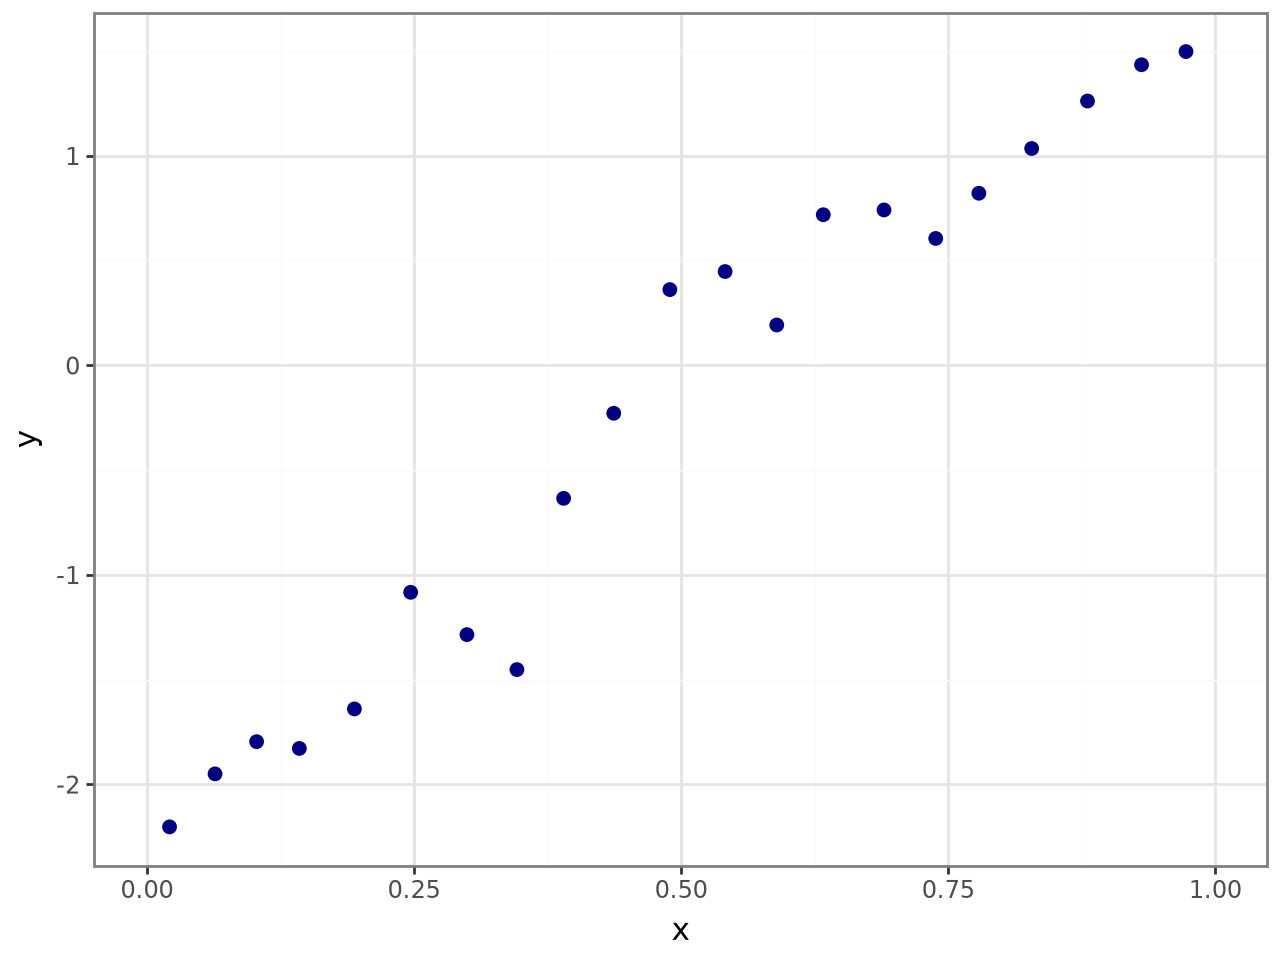

In [18]:
# Estimate 0.25 quantile
est = binsqreg('y', 'x', 'w', data=data, quantile=0.25)
est.bins_plot

C:\Users\zypub\Documents\github\my-projects\alphaecon\.venv\Lib\site-packages\binsreg\funs.py:1248: IterationLimitWarning: Maximum number of iterations (1000) reached.


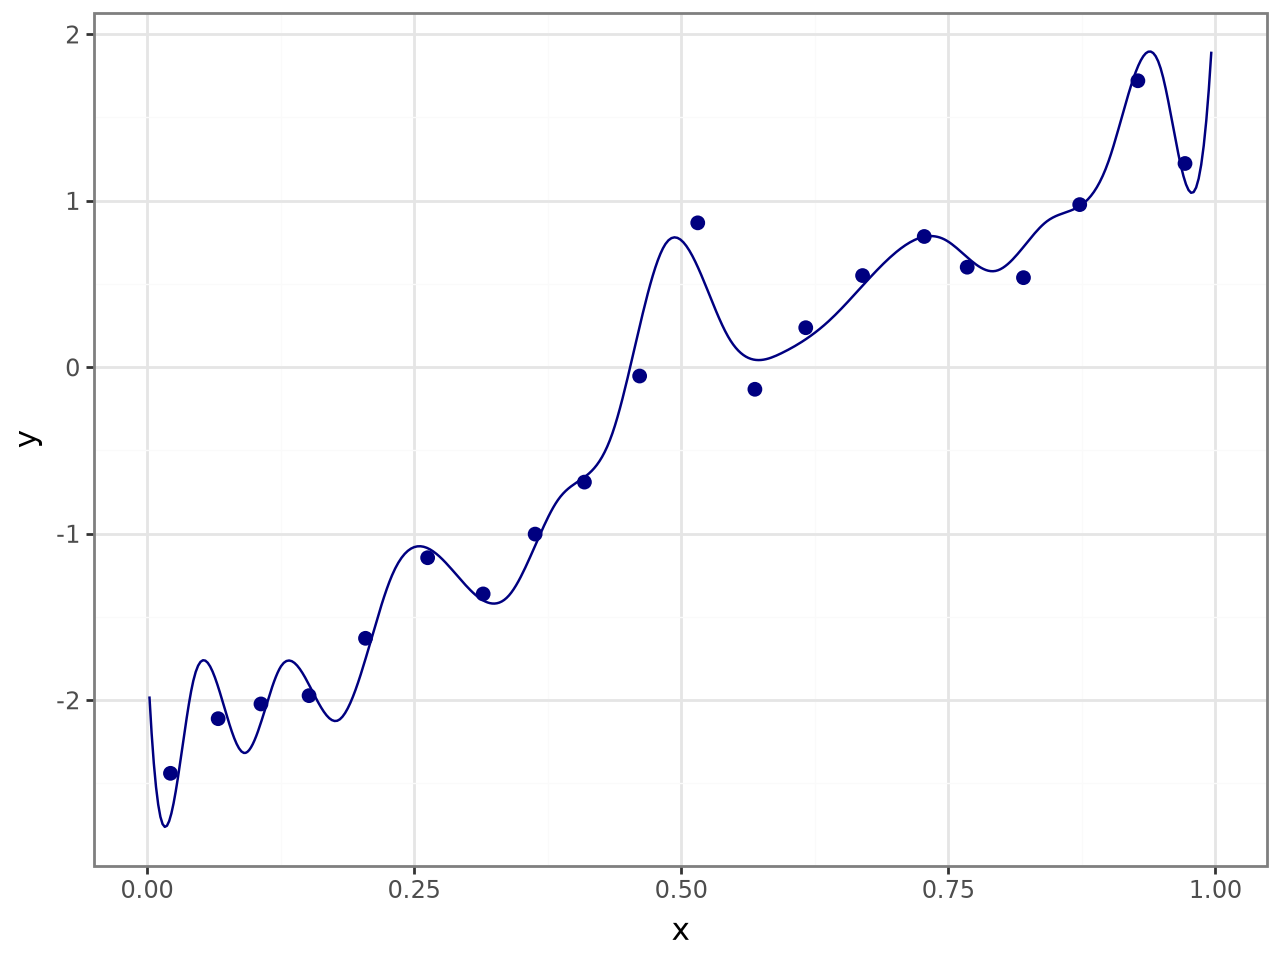

In [19]:
# Estimate 0.25  and line = (3,3)
est_25   = binsqreg('y', 'x', data = data, quantile=0.25, line=(3,3))

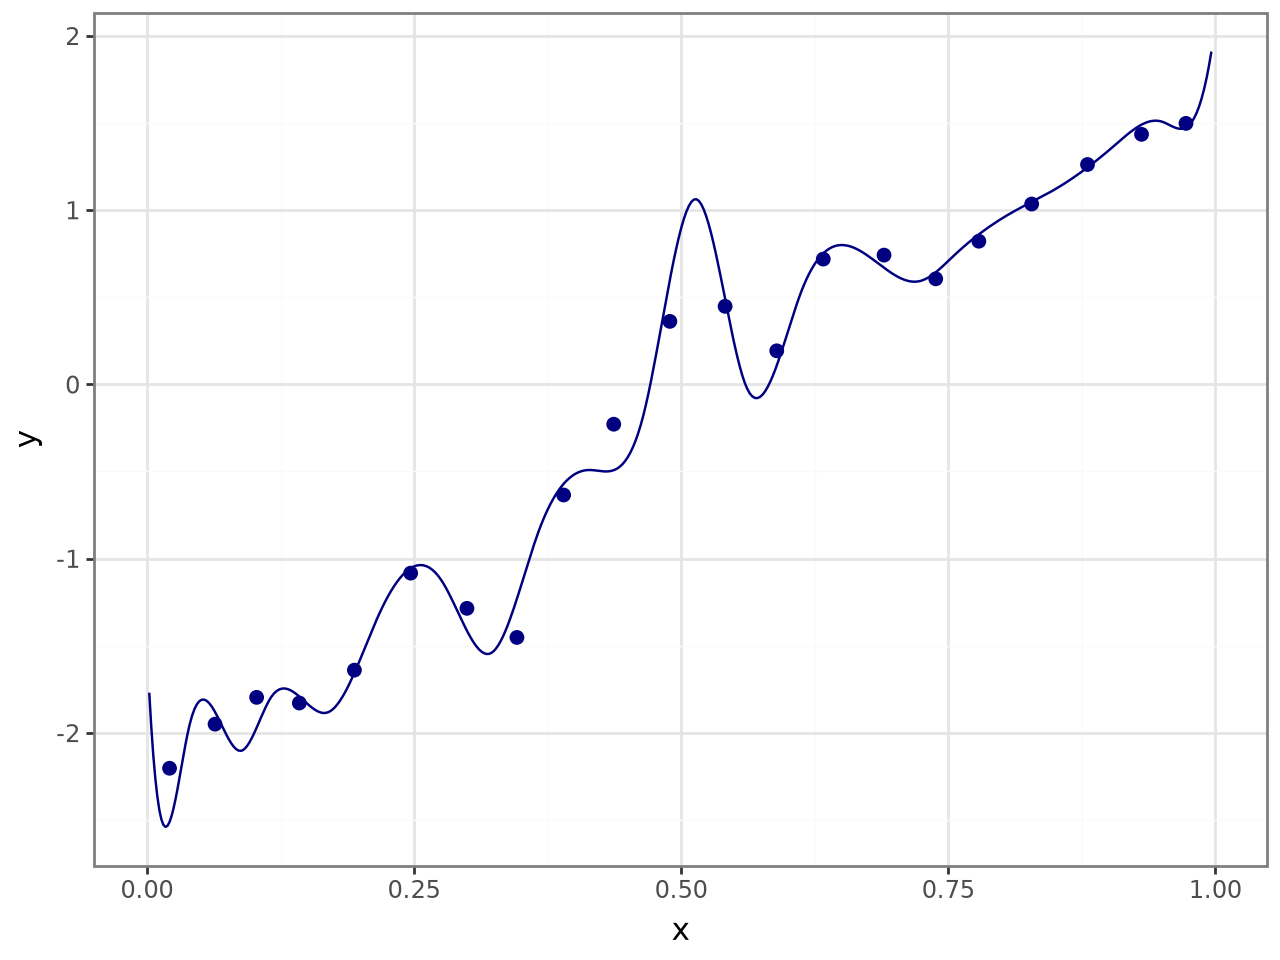

In [20]:
# Increase the number of iterations
out = binsqreg('y', 'x', 'w', data=data, quantile=0.25, line=(3,3), max_iter = 5000)

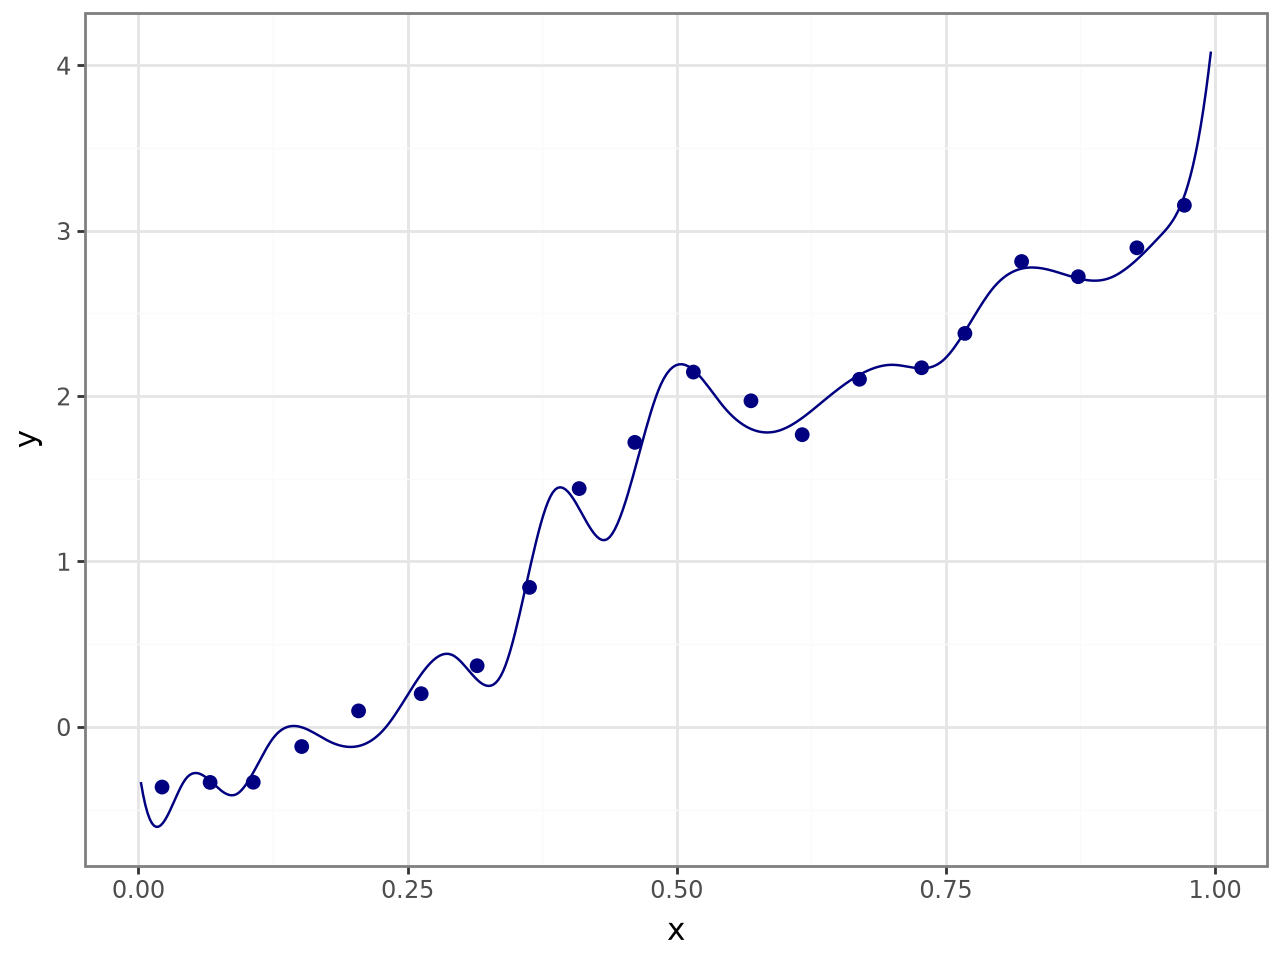

Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.


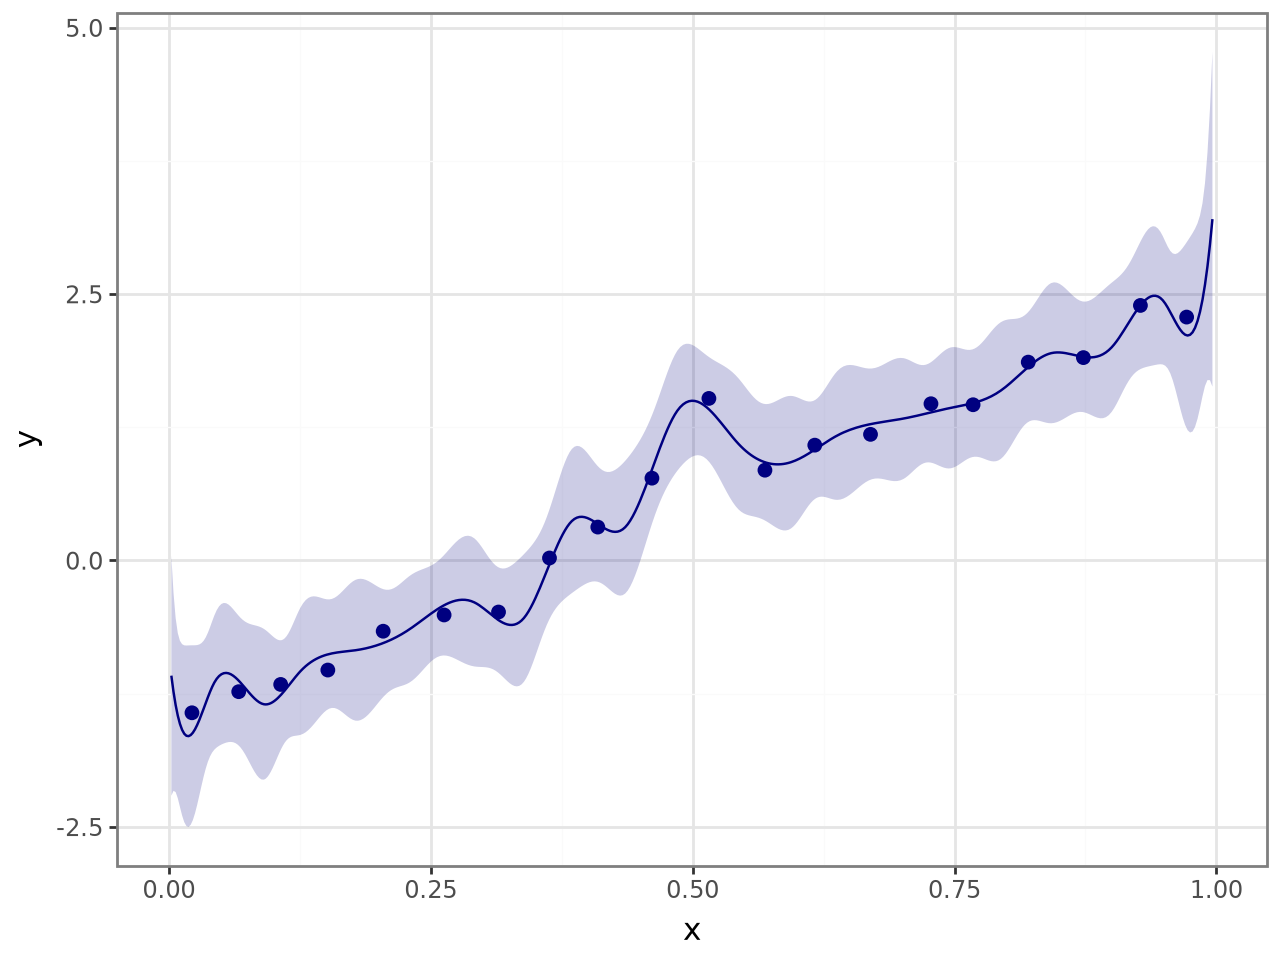

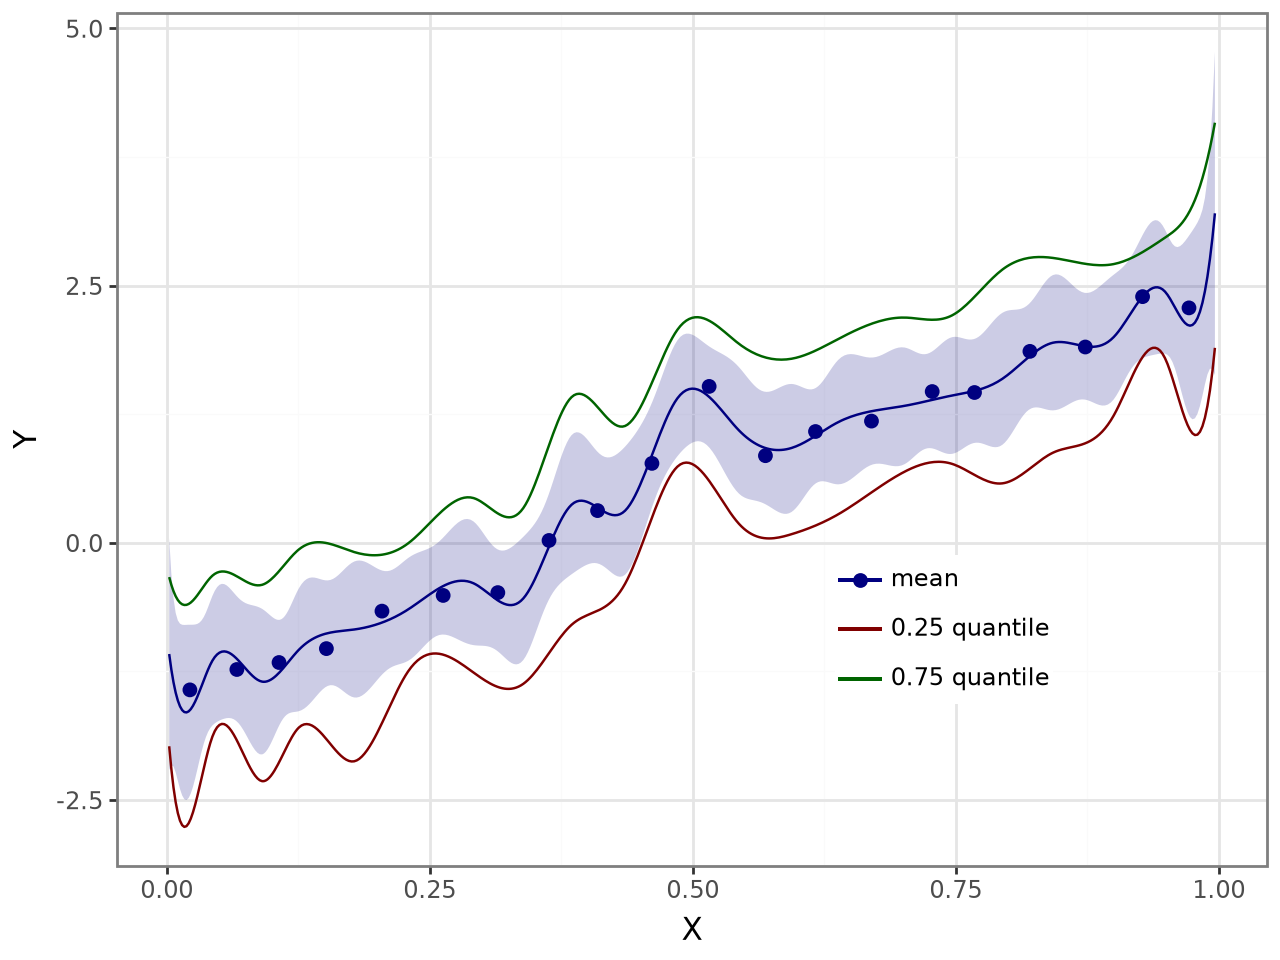

In [21]:
# Estimate 0.25 and 0.75 quantiles and combine them with the results from binsreg
dat_25   = est_25.data_plot[0].line
dat_25.insert(0,"id","0.25 quantile")
est_75   = binsqreg('y', 'x', data=data, quantile=0.75, line=(3,3), max_iter = 5000)
dat_75   = est_75.data_plot[0].line
dat_75.insert(0,"id","0.75 quantile")
est_mean = binsreg('y', 'x', data=data, line=(3,3), cb=(3,3))
dat_mean_dots = est_mean.data_plot[0].dots
dat_mean_line = est_mean.data_plot[0].line
dat_mean_cb   = est_mean.data_plot[0].cb
dat_mean_dots.insert(0,"id", "mean") 
dat_mean_line.insert(0,"id", "mean") 

fig = ggplot() + theme_bw() + labs(x="X", y="Y")
fig += theme(legend_position = (0.77,0.23),
             legend_title = element_blank(),
             legend_background = element_rect(fill = 'white'),
             legend_key = element_blank())
fig += geom_point(data=dat_mean_dots, mapping = aes(x ='x', y='fit', colour='id'), size=2)
fig += geom_line(data=dat_mean_line, mapping = aes(x ='x', y='fit', colour='id'))
fig += geom_ribbon(data=dat_mean_cb, mapping = aes(x ='x', ymin='cb_l', ymax='cb_r'), alpha=0.2, fill="navy")
fig += geom_line(data=dat_25, mapping = aes(x ='x', y='fit', colour='id'))
fig += geom_line(data=dat_75, mapping = aes(x ='x', y='fit', colour='id'))
fig += scale_color_manual(name="", values = ("navy", "maroon","darkgreen"),
                                     guide=guide_legend(override_aes = {    
                                        'linetype':["solid"]*3, 'shape':('o', 'None', 'None')}))
fig

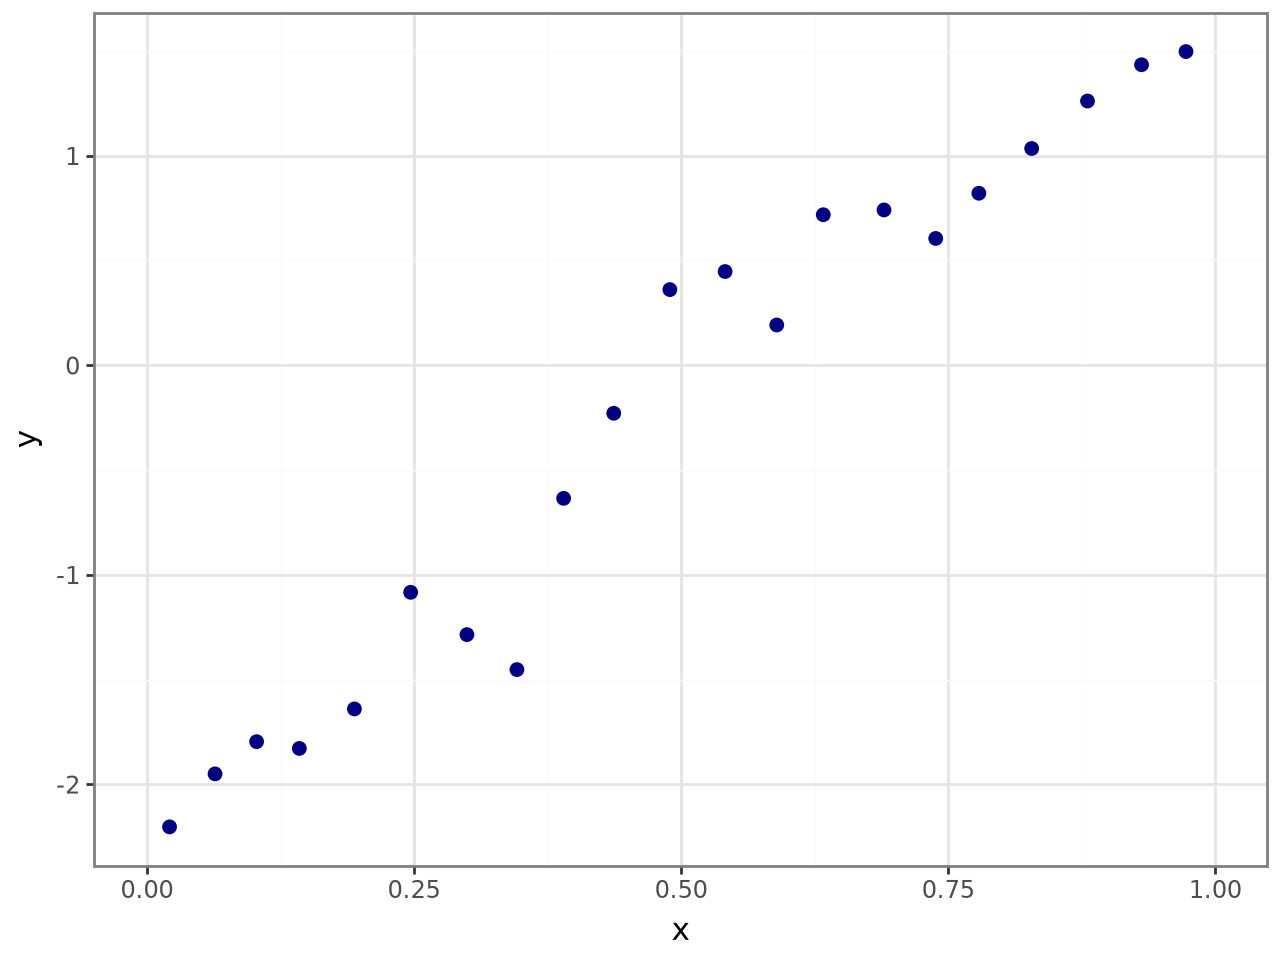

Call: binsqreg

Binscatter Plot
Bin/Degree selection method (binsmethod) =  IMSE direct plug-in (select # of bins)
Placement (binspos)                      =                         Quantile-spaced
Derivative (deriv)                       =                                       0
Quantile                                 =                                    0.25
 
Group (by)                               =                             Full Sample
Sample size (n)                          =                                    1000
# of distinct values (Ndist)             =                                    1000
# of clusters (Nclust)                   =                                     nan
dots, degree (p)                         =                                       0
dots, smooth (s)                         =                                       0
# of bins (nbins)                        =                                      21




In [22]:
# Control for the fitting process, e.g., the maximum number of iterations and tolerance
binsqreg('y', 'x', 'w', data=data, quantile=0.25, max_iter = 5000, p_tol = 1e-6)

# BINSGLM

# `binsglm`

The `binsglm` function in `Python/binsreg/src/binsreg/binsglm.py` implements data-driven binscatter generalized linear regression with robust inference and plotting. It estimates the mean relationship between `y` and `x` under a GLM family, optionally adjusting for controls `w`, and supports binscatter-style points, fitted lines, confidence intervals, confidence bands, subgroup analysis, and automatic bin selection.

## Overview

`binsglm` is designed for:

- generalized linear models with binscatter-style partitioning
- plot construction with dots, fitted lines, confidence intervals, and uniform confidence bands
- covariate adjustment via `w`
- subgroup analysis via `by`
- heteroskedastic-robust and cluster-robust inference
- data-driven bin selection when `nbins` is not fixed by the user

It is the GLM companion to `binsreg` and is commonly used alongside `binsregselect`, `binsqreg`, `binstest`, and `binspwc`.

## Function signature

```python
binsglm(
    y,
    x,
    w=None,
    data=None,
    at=None,
    dist="Gaussian",
    link=None,
    deriv=0,
    nolink=False,
    dots=None,
    dotsgrid=0,
    dotsgridmean=True,
    line=None,
    linegrid=20,
    ci=None,
    cigrid=0,
    cigridmean=True,
    cb=None,
    cbgrid=20,
    polyreg=None,
    polyreggrid=20,
    polyregcigrid=0,
    by=None,
    bycolors=None,
    bysymbols=None,
    bylpatterns=None,
    legendTitle=None,
    legendoff=False,
    nbins=None,
    binspos="qs",
    binsmethod="dpi",
    nbinsrot=None,
    pselect=None,
    sselect=None,
    samebinsby=False,
    randcut=None,
    nsims=500,
    simsgrid=20,
    simsseed=None,
    vce="HC1",
    cluster=None,
    asyvar=False,
    level=95,
    noplot=False,
    dfcheck=(20, 30),
    masspoints="on",
    weights=None,
    subset=None,
    plotxrange=None,
    plotyrange=None,
    **optimize,
)
```

## Inputs and parameters

### Main data inputs

- `y`: outcome variable. Can be a vector or a column name when `data` is supplied.
- `x`: regressor of interest. Can be a vector or a column name when `data` is supplied.
- `w`: optional control variables. Can be a vector, matrix, or a list of column names when `data` is supplied.
- `data`: optional pandas DataFrame containing the variables used in the model.
- `at`: value(s) of `w` at which the estimated function is evaluated. Common settings are `"mean"`, `"median"`, or `"zero"`.
- `dist`: GLM family distribution. Common values include `"Gaussian"`, `"Binomial"`, `"Gamma"`, and `"Poisson"`.
- `link`: link function used with `dist`, such as `"Identity"`, `"Logit"`, `"Log"`, or `"Probit"`.
- `nolink`: if `True`, reports the function on the inverse-link scale instead of the conditional mean.
- `deriv`: derivative order to estimate. `0` estimates the function itself; `1` is allowed when `nolink=False`.
- `weights`: optional observation weights.
- `subset`: optional subset selector for observations.

### Plotting controls

- `dots`: binscatter dots specification. Typical usage is `dots=(p, s)`, where `p` is the polynomial degree and `s` is the smoothness constraint. If `dots=True`, a default binscatter is used.
- `dotsgrid`: number of evaluation points per bin for plotting dots.
- `dotsgridmean`: whether to include the bin-mean evaluation point in the plotted dots.
- `line`: line overlay specification, used for a smoothed fitted line.
- `linegrid`: grid resolution used for evaluating the line.
- `ci`: pointwise confidence interval specification.
- `cigrid`: grid resolution used for confidence interval construction.
- `cigridmean`: whether to include bin-mean confidence intervals.
- `cb`: uniform confidence band specification.
- `cbgrid`: grid resolution used for confidence band construction.
- `polyreg`: optional global polynomial regression to overlay.
- `polyreggrid`: grid resolution for the polynomial fit.
- `polyregcigrid`: grid resolution for polynomial confidence intervals.
- `noplot`: if `True`, suppresses plot creation while still returning plotting data.
- `plotxrange` and `plotyrange`: x- and y-axis ranges for the plot.

### Subgroup analysis and legend styling

- `by`: grouping variable for subgroup analysis. Separate GLM curves are estimated for each group.
- `bycolors`, `bysymbols`, `bylpatterns`: styling controls for subgroup series.
- `legendTitle`: title shown in the plot legend.
- `legendoff`: if `True`, hides the legend.
- `samebinsby`: if `True`, forces a common set of bins across groups.

### Binning and model selection

- `nbins`: number of bins. If omitted or set to `True`, the number of bins is selected automatically.
- `binspos`: binning position rule. Default is `"qs"` for quantile-spaced bins.
- `binsmethod`: selection method for bin count. Default is `"dpi"` (direct plug-in); `"rot"` is an alternative.
- `nbinsrot`: initial number of bins used in constructing the DPI selector.
- `pselect`, `sselect`: candidate values used when selecting the polynomial degree and smoothness constraints.
- `randcut`: random subsample cutoff used in selection procedures for large samples.

### Inference and robustness

- `nsims`: number of simulations used for confidence band construction.
- `simsgrid`: grid resolution used in the supremum approximation for confidence bands.
- `simsseed`: random seed for reproducible simulations.
- `vce`: variance estimator. The default is `"HC1"`.
- `cluster`: cluster ID used to compute cluster-robust standard errors.
- `asyvar`: if `True`, ignores uncertainty from control variables when computing the standard error of the nonparametric component.
- `level`: nominal confidence level for intervals/bands, expressed as a percentage.
- `dfcheck`: minimum effective sample size checks used to guard against overfitting or weak identification.
- `masspoints`: rule for handling repeated values (mass points) in `x`.

### Optimizer options

- `**optimize`: optional arguments passed to the `statsmodels` GLM optimizer.

## Return value

The function returns:

- `bins_plot`: a `ggplot` object suitable for display or saving.
- `data_plot`: a nested list of plotting datasets, one per subgroup if `by` is used.

The plotting data may include DataFrames for:

- `dots`: fitted dot estimates
- `line`: fitted line estimates
- `ci`: pointwise confidence intervals
- `cb`: uniform confidence band
- `poly`: global polynomial regression fit
- `polyci`: polynomial regression confidence intervals
- `data_bin`: binning structure summary
- `imse_v_rot`, `imse_b_rot`, `imse_v_dpi`, `imse_b_dpi`: IMSE selection constants
- `cval_by`: critical values for confidence bands by group
- `options`: option metadata and sample-size diagnostics

## Implementation notes

The function:

1. extracts variables from `data` when column names are supplied
2. reshapes and filters inputs, including `subset` handling and missing-value removal
3. determines the GLM family and inverse-link machinery
4. validates the requested binning, polynomial, and inference settings
5. selects bins and polynomial degrees when needed
6. computes GLM-based binscatter estimates and associated uncertainty
7. returns plotting objects and diagnostic data

If `nbins` is not specified, `binsregselect` is used to choose the binning in a data-driven way.

## Example usage

```python
import numpy as np
from binsreg.binsglm import binsglm

x = np.random.uniform(size=500)
d = (np.random.uniform(size=500) <= x).astype(int)

out = binsglm(d, x, dist="Binomial")
print(out)
```

A more complete example with controls and subgroup analysis:

```python
import pandas as pd
from binsreg.binsglm import binsglm

df = pd.DataFrame({
    "y": [0, 1, 1, 0, 1, 0],
    "x": [0.1, 0.4, 0.8, 1.2, 1.8, 2.5],
    "w1": [1.0, 0.5, 1.2, 0.8, 1.7, 2.0],
    "group": ["A", "A", "B", "B", "B", "A"],
})

result = binsglm(
    y="y",
    x="x",
    w="w1",
    data=df,
    by="group",
    dist="Binomial",
    link="Logit",
    dots=(0, 0),
    line=(1, 1),
    ci=(1, 1),
    cb=(1, 1),
    nbins=10,
)
```

## Notes

- `dist` and `link` should be chosen consistently.
- `nolink=True` changes the reported scale to the inverse-link scale.
- If `data` is supplied, strings can be used for `x`, `y`, `w`, `by`, `cluster`, and `weights`.
- `samebinsby=True` forces a common binning structure across subgroups.

## See also

- `binsregselect`: data-driven binscatter partition selection
- `binsreg`: least-squares binscatter estimation and plotting
- `binsqreg`: binscatter quantile regression
- `binstest`: binscatter-based hypothesis testing
- `binspwc`: pairwise comparisons of binscatter estimators

## References

The implementation follows the binscatter methods and testing framework developed in:

- Cattaneo, M. D., Crump, R. K., Farrell, M. H., and Feng, Y. (2024)
- Cattaneo, M. D., Crump, R. K., Farrell, M. H., and Feng, Y. (2026)


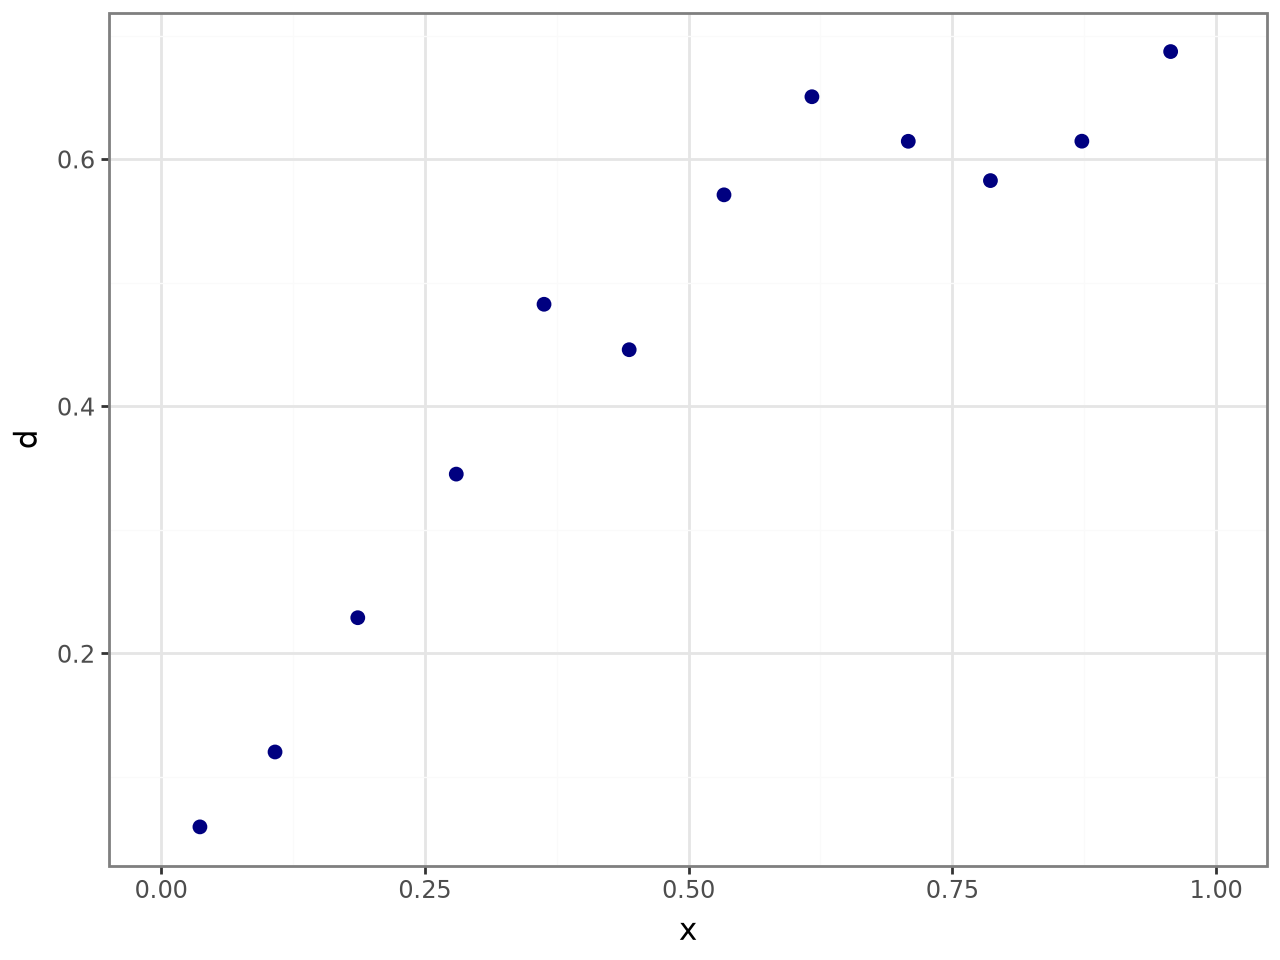

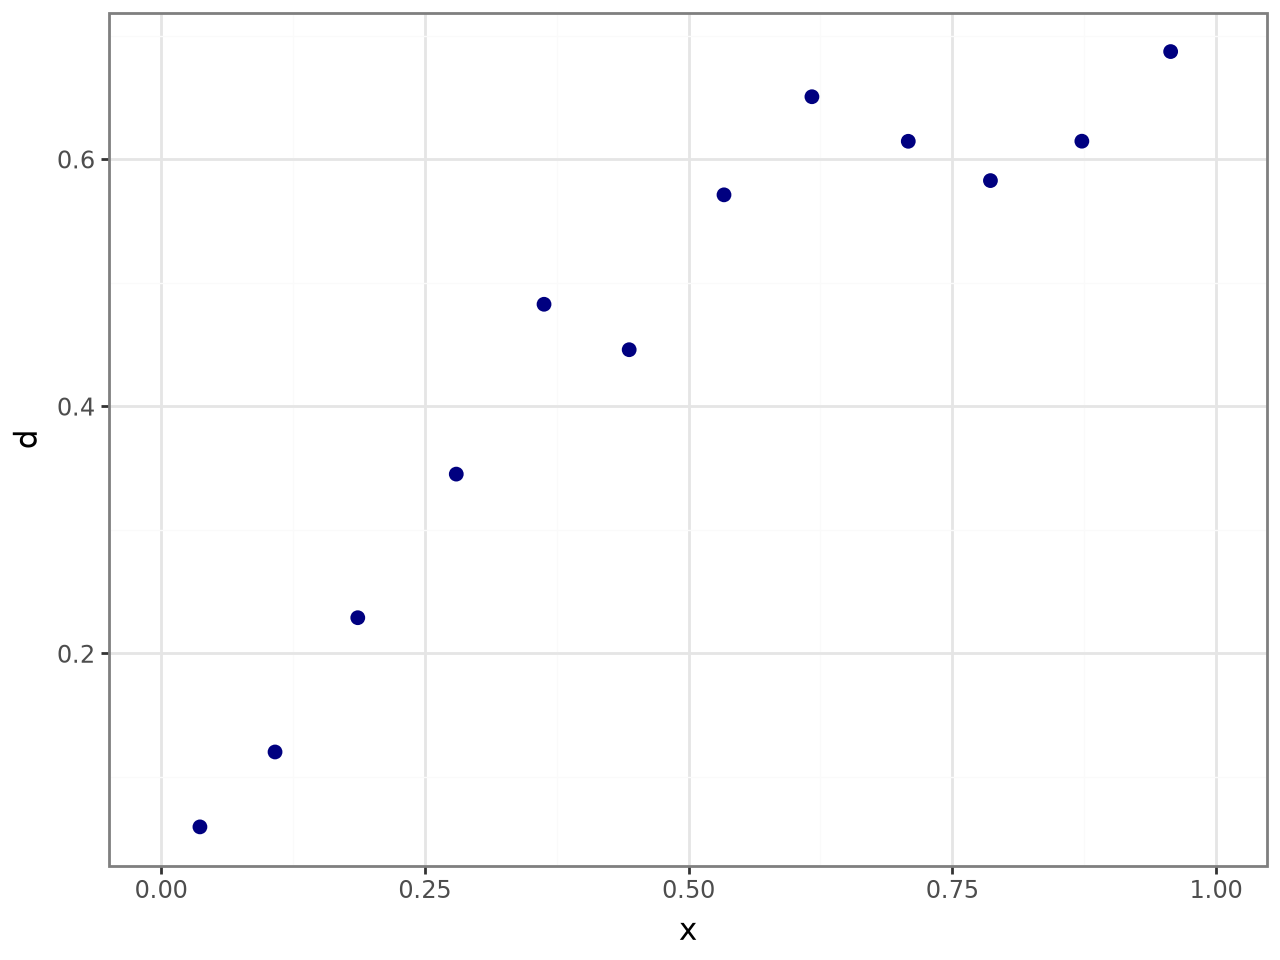

In [23]:
# Basic syntax: binscatter logistic regression
est = binsglm('d', 'x', 'w', data=data, dist = 'Binomial')
est.bins_plot

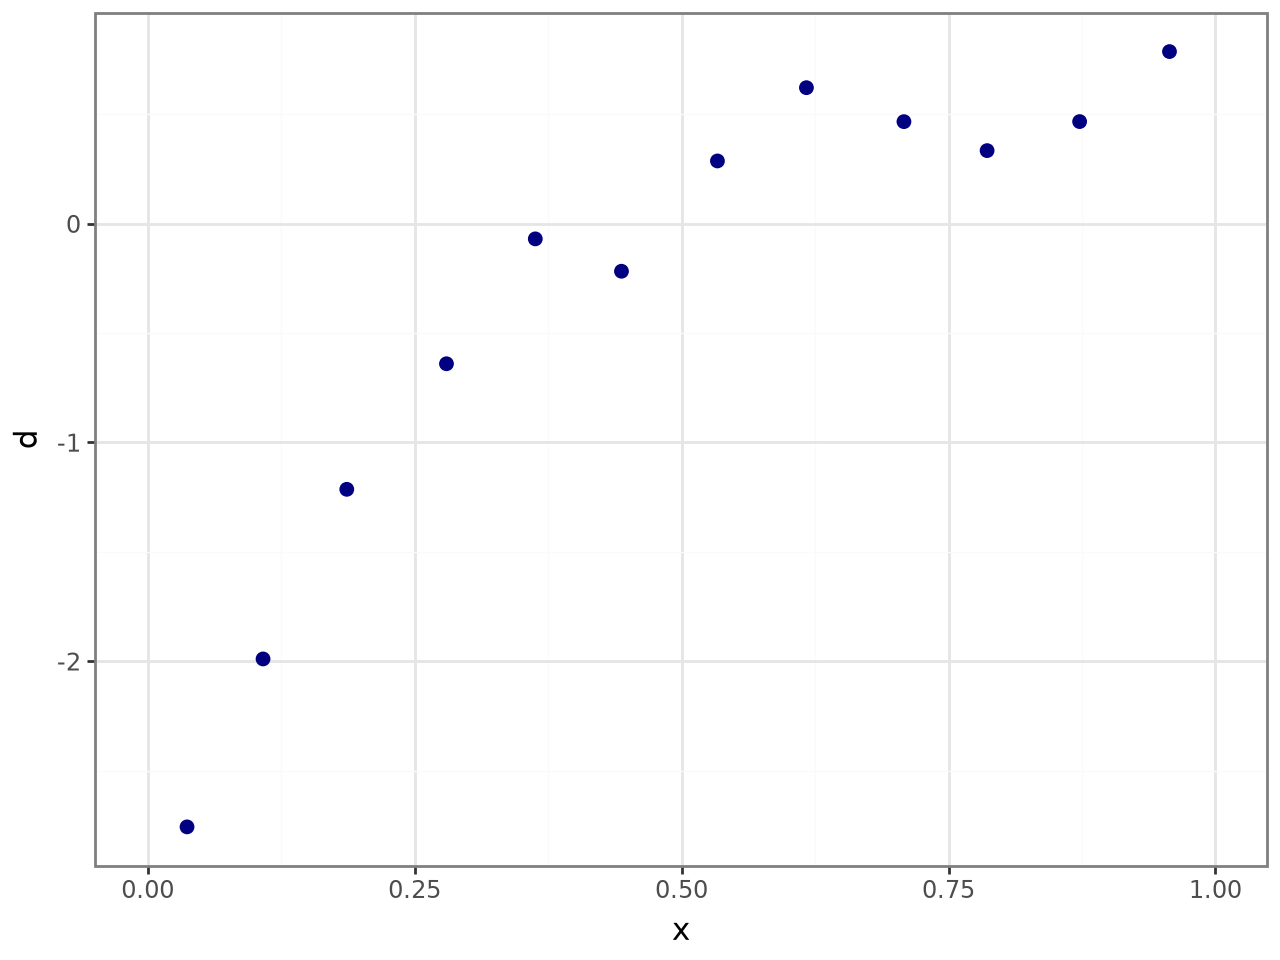

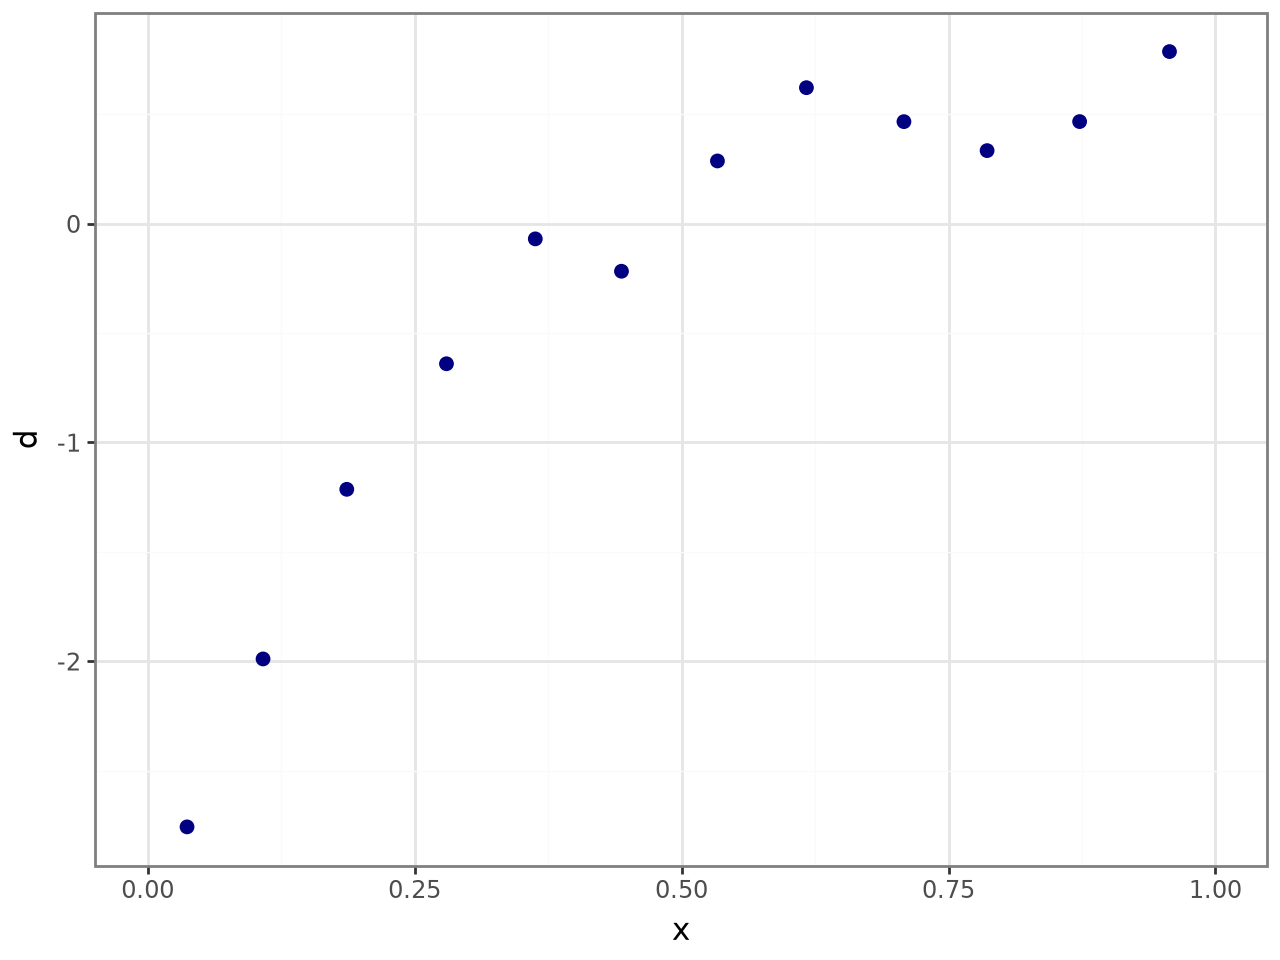

In [24]:
# Plot the function in the inverse link (logistic) function rather than the conditional probability
est = binsglm('d', 'x', 'w', data=data, dist = 'Binomial', nolink = True)
est.bins_plot

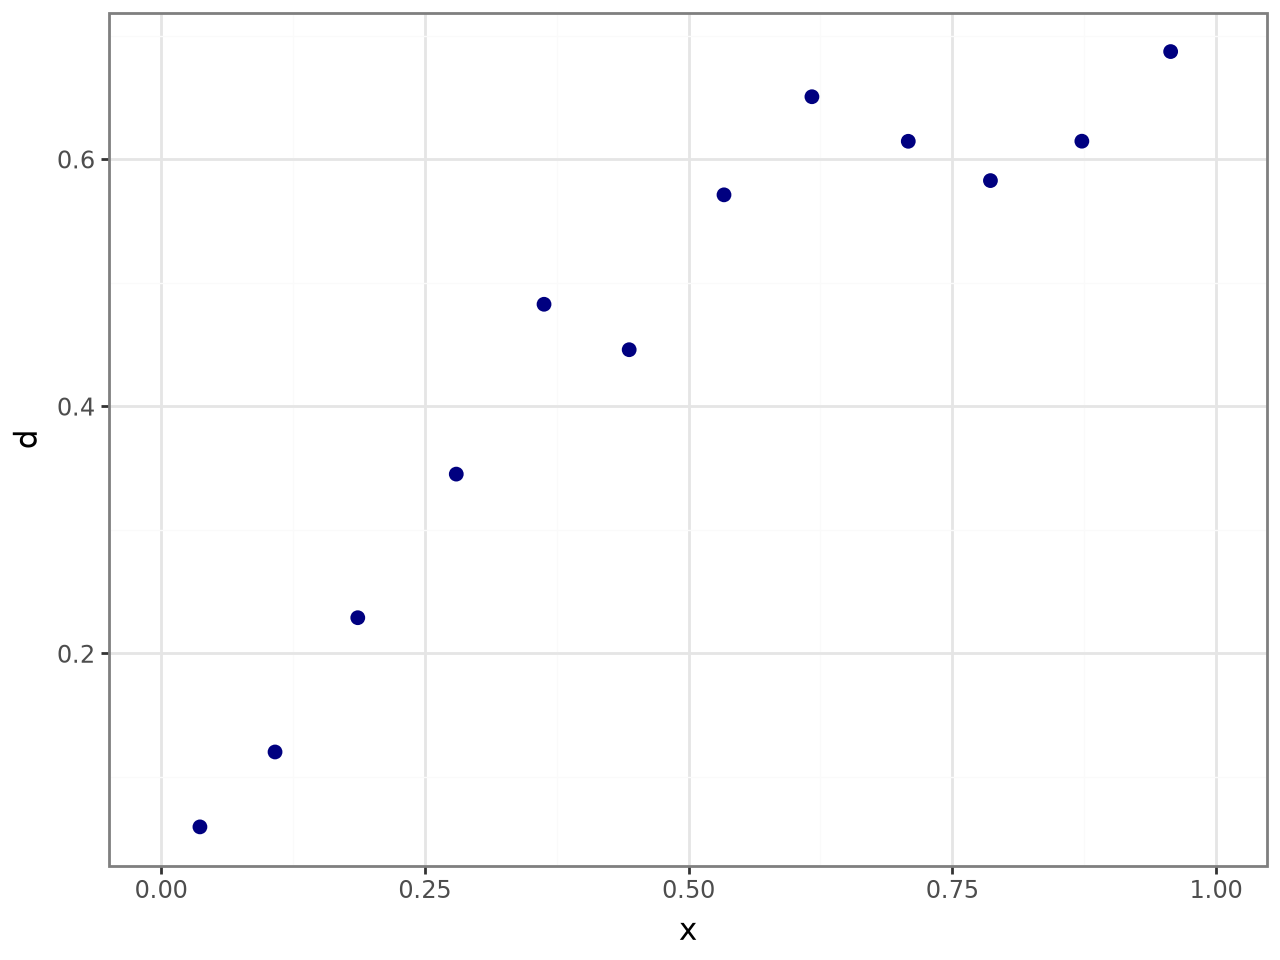

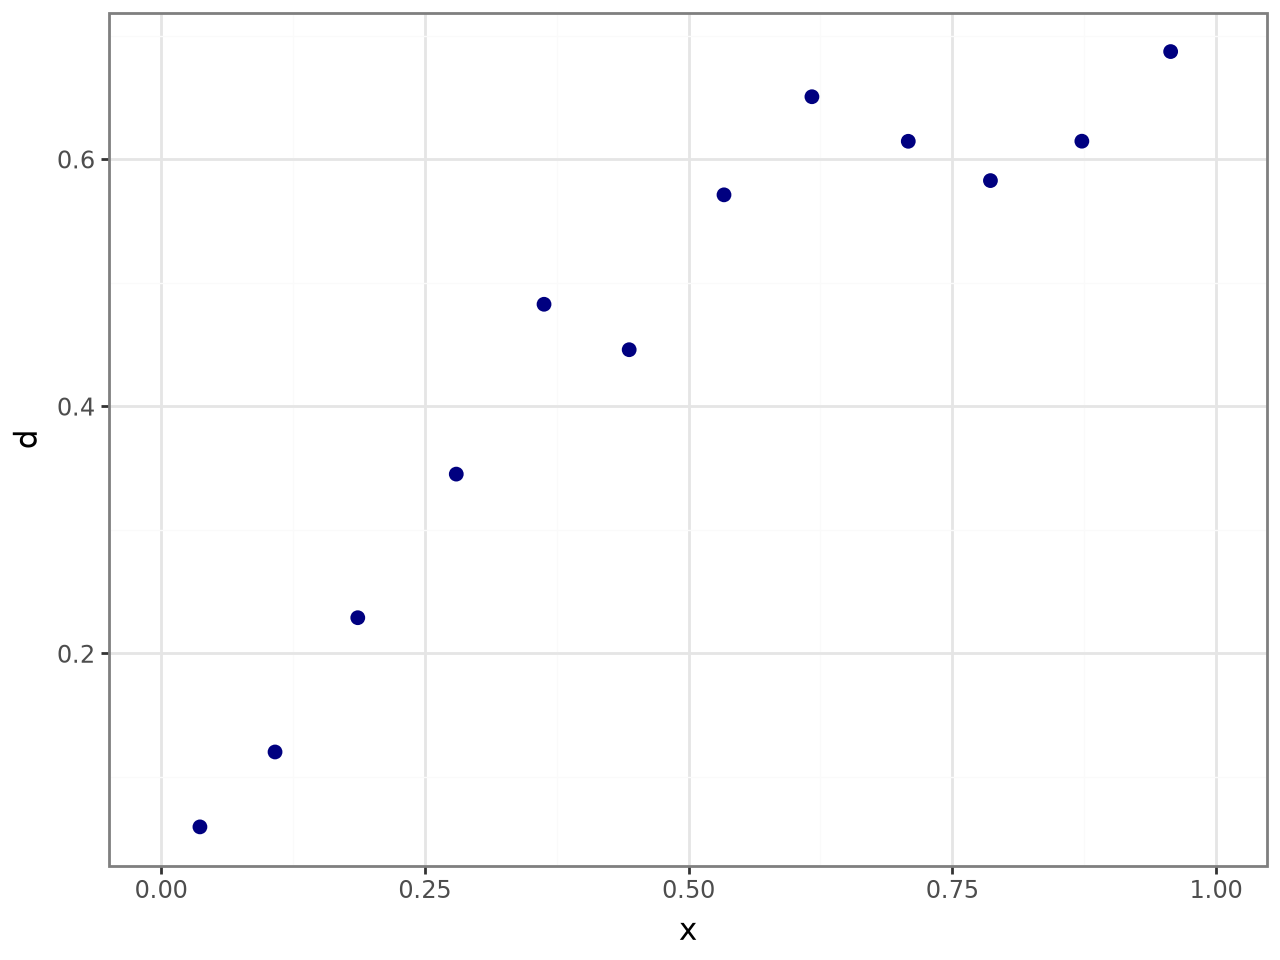

In [25]:
# Control for the fitting process, e.g., the maximum number of iterations and tolerance
est = binsglm('d', 'x', 'w', data=data, dist = 'Binomial', maxiter = 100, tol = 1e-6)
est.bins_plot

# BINSTEST

# `binstest`

The `binstest` function in `Python/binsreg/src/binsreg/binstest.py` implements binscatter-based hypothesis tests for parametric specification and shape restrictions in a regression function. It is designed for testing whether the conditional mean (or other estimands) follows a particular parametric form or satisfies a nonparametric shape restriction, while allowing data-driven bin selection, robust variance estimation, and inference based on binscatter approximations.

## Overview

`binstest` is used to evaluate hypotheses such as:

- a parametric model is correctly specified
- a function satisfies a shape restriction such as monotonicity, boundedness, or a one-/two-sided null boundary condition
- a nonparametric binscatter fit is statistically distinguishable from a simpler model

The function wraps binscatter estimation with test statistics computed from local polynomial approximations, robust bias correction, and simulation-based confidence bands or supremum-norm tests when needed. It is typically paired with `binsreg`, `binsregselect`, `binsqreg`, `binsglm`, and `binspwc`.

## Function signature

```python
binstest(
    y,
    x,
    w=None,
    data=None,
    estmethod="reg",
    dist=None,
    link=None,
    quantile=None,
    deriv=0,
    at=None,
    nolink=False,
    testmodel=None,
    testmodelparfit=None,
    testmodelpoly=None,
    testshape=None,
    testshapel=None,
    testshaper=None,
    testshape2=None,
    lp=np.inf,
    bins=None,
    nbins=None,
    pselect=None,
    sselect=None,
    binspos="qs",
    binsmethod="dpi",
    nbinsrot=None,
    randcut=None,
    nsims=500,
    simsgrid=20,
    simsseed=None,
    vce=None,
    cluster=None,
    asyvar=False,
    dfcheck=(20, 30),
    masspoints="on",
    weights=None,
    subset=None,
    numdist=None,
    numclust=None,
    estmethodopt=None,
    **optmize,
)
```

## Inputs and parameters

### Main data inputs

- `y`: outcome variable. Can be a vector or a column name when `data` is supplied.
- `x`: regressor of interest. Can be a vector or a column name when `data` is supplied.
- `w`: optional control variables. Can be a vector, matrix, or a list of column names when `data` is supplied.
- `data`: optional pandas DataFrame containing the variables used in the model.
- `weights`: optional observation weights.
- `subset`: optional subset selector to use a restricted sample.
- `cluster`: optional cluster identifiers for cluster-robust inference.

### Estimation method and functional form

- `estmethod`: estimation method for the underlying binscatter fit. Accepted values are:
  - `"reg"` for least-squares regression (default)
  - `"qreg"` for quantile regression
  - `"glm"` for generalized linear models
- `dist`: distribution for GLM estimation; examples include `"Gaussian"`, `"Binomial"`, `"Gamma"`, and `"Poisson"`.
- `link`: link function associated with `dist`, such as `"identity"`, `"logit"`, `"log"`, or `"probit"`.
- `quantile`: target quantile for quantile-regression tests. Must be in `(0, 1)`.
- `deriv`: derivative order of the regression function being tested or estimated. Defaults to `0`.
- `at`: evaluation point(s) for `w` at which the function is evaluated. Common choices are `"mean"`, `"median"`, or `"zero"`, or a vector/data frame of covariate values.
- `nolink`: if `True`, the non-link-transformed index is reported instead of the conditional mean.

### Parametric model specification tests

The tests in `binstest` target departures from parametric models or restrictions on the estimated nonparametric function.

- `testmodel`: specifies the parametric model used in the specification test. If it is a tuple `(p, s)`, the test uses a piecewise polynomial of degree `p` with `s` smoothness constraints. If `True` or `None`, the default is typically `(1, 1)` unless degree/smoothness selection is requested via `pselect` or `sselect`.
- `testmodelparfit`: evaluation grid and fitted values for a parametric benchmark model(s) to be tested against.
- `testmodelpoly`: degree of a global polynomial model to be tested against.
- `lp`: norm used for the test statistic. The default is `np.inf`, which corresponds to the supremum-norm version. Other positive values `p >= 1` are allowed.
- `pselect`: candidate polynomial degrees for selecting the test model.
- `sselect`: candidate smoothness choices for selecting the test model.

### Shape restriction tests

- `testshape`: general shape restriction test specification, using a piecewise polynomial of degree `p` and smoothness `s`.
- `testshapel`: vector of left-side null boundary values for hypotheses of the form `H0: sup_x mu(x) <= a`.
- `testshaper`: vector of right-side null boundary values for hypotheses of the form `H0: inf_x mu(x) >= a`.
- `testshape2`: vector of null boundary values for two-sided tests of the form `H0: sup_x |mu(x) - a| = 0`.

### Binning and model selection

- `bins`: tuple `(p, s)` specifying the piecewise polynomial degree and smoothness used for data-driven partition selection.
- `nbins`: number of bins for partitioning. If `True` or `None`, it is selected by `binsregselect` in a data-driven way whenever appropriate.
- `binspos`: bin placement rule. Default is `"qs"` for quantile-spaced bins, with `"es"` available for evenly spaced bins.
- `binsmethod`: method to select the number of bins. Default is `"dpi"` (direct plug-in). `"rot"` is an alternative rule-of-thumb selector.
- `nbinsrot`: initial number of bins used for the DPI selector.
- `randcut`: subsample cutoff used in selection procedures for large samples.
- `numdist`: number of distinct `x` values used to speed up selection computations.
- `numclust`: number of clusters used to speed up selection computations.

### Inference and robustness

- `nsims`: number of Monte Carlo draws used to approximate the distribution of the test statistic or confidence band.
- `simsgrid`: number of evaluation points within each bin used for the supremum approximation in confidence bands or tests.
- `simsseed`: random seed for reproducible simulation draws.
- `vce`: variance estimator. Options include `"const"`, `"HC0"`, `"HC1"`, `"HC2"`, and `"HC3"`; the default is `"HC1"` when unspecified.
- `asyvar`: if `True`, the standard error calculation omits uncertainty due to control variables.
- `dfcheck`: minimum effective sample size checks used to guard against overfitting or weak identification. Default is `(20, 30)`.
- `masspoints`: rules for handling repeated values in `x` (`"on"`, `"noadjust"`, `"nolocalcheck"`, `"off"`, `"veryfew"`).
- `estmethodopt`: optional arguments to the optimizer used by GLM or quantile-regression methods.

## Return value

`binstest` returns a dictionary-like collection of results, including the outputs of the different hypothesis tests and the auxiliary selection quantities used to construct the tests.

Typical entries include:

- `testshapeL`: results for left-sided shape restriction tests, including `val`, `stat`, and `pval`
- `testshapeR`: results for right-sided shape restriction tests, including `val`, `stat`, and `pval`
- `testshape2`: results for two-sided shape restriction tests, including `val`, `stat`, and `pval`
- `testpoly`: results for polynomial specification tests, including `val`, `stat`, and `pval`
- `testmodel`: results for parametric model comparison tests, including `val`, `stat`, and `pval`
- `imse_v_rot`: variance constant in the IMSE criterion for ROT selection
- `imse_b_rot`: bias constant in the IMSE criterion for ROT selection
- `imse_v_dpi`: variance constant in the IMSE criterion for DPI selection
- `imse_b_dpi`: bias constant in the IMSE criterion for DPI selection
- `options`: a record of the options used, together with sample-size diagnostics such as `n`, number of distinct `x` values, number of clusters, and selected number of bins

## Implementation notes

The function performs the following main steps:

1. validates and prepares the data (`x`, `y`, `w`, cluster, weights, subset)
2. drops missing values in all relevant inputs
3. determines the estimation method and variance estimator
4. sets up the testing tasks for parametric specification and/or shape restrictions
5. selects the partitioning and polynomial/smoothness choices when `nbins`, `pselect`, or `sselect` are unspecified
6. computes the binscatter-based test statistics and p-values
7. returns the results and diagnostics for interpretation or plotting

A key feature of the implementation is that if the binning scheme is not specified by the user, it relies on the companion function `binsregselect` to choose the bins in a data-driven, IMSE-optimal way.

## Example usage

```python
import numpy as np
from binsreg.binstest import binstest

x = np.random.uniform(size=500)
y = np.sin(x) + np.random.normal(size=500)

out = binstest(y, x, testmodelpoly=1)
print(out)
```

A more complete example with controls and a parametric model test:

```python
import pandas as pd
from binsreg.binstest import binstest

df = pd.DataFrame({
    "y": [0.5, 1.2, 2.0, 3.1, 4.0, 5.5],
    "x": [0.1, 0.4, 0.8, 1.2, 1.8, 2.5],
    "w1": [1.0, 0.5, 1.2, 0.8, 1.7, 2.0],
})

result = binstest(
    y="y",
    x="x",
    w="w1",
    data=df,
    testmodel=(1, 1),
    nbins=10,
    level=95,
)
```

## Notes

- The default behavior is data-driven and robust, especially for large samples.
- `testmodel`, `testshape`, and related restrictions can be used to evaluate parametric adequacy or shape restrictions using binscatter approximations.
- The supremum-norm (`lp = np.inf`) is especially important for one-sided shape restriction tests.
- When `estmethod="glm"`, `dist` and optionally `link` must be specified appropriately.
- If `data` is supplied, strings can be used for `x`, `y`, `w`, `cluster`, and `weights`.

## See also

- `binsregselect`: data-driven binscatter partition selection
- `binsreg`: least-squares binscatter estimation and plotting
- `binsqreg`: binscatter quantile regression
- `binsglm`: binscatter generalized linear models
- `binspwc`: pairwise comparison of binscatter estimators

## References

The implementation follows the binscatter methods and testing framework developed in:

- Cattaneo, M. D., Crump, R. K., Farrell, M. H., and Feng, Y. (2024)
- Cattaneo, M. D., Crump, R. K., Farrell, M. H., and Feng, Y. (2026)

The method is designed for shape-restricted and specification-testing procedures in nonparametric regression using binscatter methods with robust bias correction.


In [26]:
# basic syntax: linearity? (default method: least squares regression)
bstest = binstest('y', 'x', 'w', data=data, testmodelpoly=1)
bstest.summary()

Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.
Call: binstest

Sample size (n)                    =   1000           
# of distinct values (Ndist)       =   1000           
# of clusters (Nclust)             =   nan            
Estimation Method (estmethod)      =   least squares regression
Derivative (deriv)                 =   0              
Bin/Degree selection:
  Method (binsmethod)              =   IMSE direct plug-in (select # of bins)
  Placement (binspos)              =   Quantile-spaced
  degree (p)                       =   0              
  smooth (s)                       =   0              
  # of bins (nbins)                =   21             

Model Specification Tests:
degree (p) =  1 ; smooth (s) =  1
H0: mu =             sup |T|      p value
-----------------------------------------
poly. p=1              6.566        0.000
-----------------------------------------


''

In [27]:
# Recommended strategy: test if 1st deriv=const
bstest = binstest('y', 'x', 'w', data=data, testmodelpoly=1, deriv=1)
bstest.summary()

Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.
Call: binstest

Sample size (n)                    =   1000           
# of distinct values (Ndist)       =   1000           
# of clusters (Nclust)             =   nan            
Estimation Method (estmethod)      =   least squares regression
Derivative (deriv)                 =   1              
Bin/Degree selection:
  Method (binsmethod)              =   IMSE direct plug-in (select # of bins)
  Placement (binspos)              =   Quantile-spaced
  degree (p)                       =   1              
  smooth (s)                       =   1              
  # of bins (nbins)                =   6              

Model Specification Tests:
degree (p) =  2 ; smooth (s) =  2
H0: mu =             sup |T|      p value
-----------------------------------------
poly. p=1              4.114        0.002
-----------------------------------------


''

In [28]:
# Alternative: save parametric fit in another data frame or matrix; use L2 metric rather than sup
# If not available, first create by using binsregselect
bins = binsregselect('y','x','w', data=data, simsgrid=30, savegrid = True)
grid = bins.data_grid
grid.insert(0,'w', np.zeros(grid.shape[0]))
ols = smf.ols('y ~ x + w', data).fit()
ols_pred = ols.predict(grid)
model = np.column_stack((grid.x, ols_pred))

bstest = binstest('y', 'x', 'w', data=data, testmodelparfit=model, lp=2, deriv=1)
bstest.summary()

Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.
Call: binstest

Sample size (n)                    =   1000           
# of distinct values (Ndist)       =   1000           
# of clusters (Nclust)             =   nan            
Estimation Method (estmethod)      =   least squares regression
Derivative (deriv)                 =   1              
Bin/Degree selection:
  Method (binsmethod)              =   IMSE direct plug-in (select # of bins)
  Placement (binspos)              =   Quantile-spaced
  degree (p)                       =   1              
  smooth (s)                       =   1              
  # of bins (nbins)                =   6              

Model Specification Tests:
degree (p) =  2 ; smooth (s) =  2
H0: mu =          L-2 of |T|      p value
-----------------------------------------
     model1            4.377        0.000
-----------------------------------------


''

In [29]:
# Shape restriction test: increasing?
bstest = binstest('y', 'x', 'w', data=data, deriv=1, nbins=20, testshaper=0)
print(bstest)

Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.
Call: binstest

Sample size (n)                    =   1000           
# of distinct values (Ndist)       =   1000           
# of clusters (Nclust)             =   nan            
Estimation Method (estmethod)      =   least squares regression
Derivative (deriv)                 =   1              
Bin/Degree selection:
  Method (binsmethod)              =   User-specified 
  Placement (binspos)              =   Quantile-spaced
  degree (p)                       =   None           
  smooth (s)                       =   None           
  # of bins (nbins)                =   20             




C:\Users\zypub\Documents\github\my-projects\alphaecon\.venv\Lib\site-packages\binsreg\binstest.py:604: UserWarning: Testing procedures are valid when nbins is much larger than the IMSE-optimal choice. Compare your choice with the IMSE-optimal one obtained by binsregselect().


In [30]:
# Test many things simultaneously
bstest = binstest('y', 'x', 'w', data=data, nbins=20, testshaper=(-2,0), testshapel=4,
                      testmodelpoly=1, nsims=1000, simsgrid=30)
print(bstest)

Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.
Call: binstest

Sample size (n)                    =   1000           
# of distinct values (Ndist)       =   1000           
# of clusters (Nclust)             =   nan            
Estimation Method (estmethod)      =   least squares regression
Derivative (deriv)                 =   0              
Bin/Degree selection:
  Method (binsmethod)              =   User-specified 
  Placement (binspos)              =   Quantile-spaced
  degree (p)                       =   None           
  smooth (s)                       =   None           
  # of bins (nbins)                =   20             




In [31]:
# Quantile regression
# Median regression: linear?
bstest = binstest('y', 'x', 'w', data=data, estmethod="qreg", quantile=0.5, testmodelpoly=1)
print(bstest)
bstest.summary()

Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.
Call: binstest

Sample size (n)                    =   1000           
# of distinct values (Ndist)       =   1000           
# of clusters (Nclust)             =   nan            
Estimation Method (estmethod)      =   quantile regression
Derivative (deriv)                 =   0              
Bin/Degree selection:
  Method (binsmethod)              =   IMSE direct plug-in (select # of bins)
  Placement (binspos)              =   Quantile-spaced
  degree (p)                       =   0              
  smooth (s)                       =   0              
  # of bins (nbins)                =   21             


Call: binstest

Sample size (n)                    =   1000           
# of distinct values (Ndist)       =   1000           
# of clusters (Nclust)             =   nan            
Estimation Method (estmethod)      =   quantile regression
Derivative (deriv)                 =   0         

''

In [32]:
# Logistic Regression
# Shape restriction test: increasing?
bstest = binstest('d', 'x', 'w', data=data, estmethod="glm", dist='Binomial',
                     deriv=1, nbins=20, testshaper=0)
print(bstest)

Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.
Call: binstest

Sample size (n)                    =   1000           
# of distinct values (Ndist)       =   1000           
# of clusters (Nclust)             =   nan            
Estimation Method (estmethod)      =   generalized linear model
Derivative (deriv)                 =   1              
Bin/Degree selection:
  Method (binsmethod)              =   User-specified 
  Placement (binspos)              =   Quantile-spaced
  degree (p)                       =   None           
  smooth (s)                       =   None           
  # of bins (nbins)                =   20             




# BINSPWC

In [33]:
# Basic syntax
bsc = binspwc('y', 'x', 'w', data=data, by='t')
print(bsc)

# Compare quantile regression functions
bsc = binspwc('y', 'x', 'w', data=data, by='t', estmethod="qreg", quantile=0.4)
print(bsc)

Note: Setting at least nsims=2000 and simsgrid=50 is recommended to obtain the final results.
Call: binspwc

Pairwise Group Comparison
Estimation Method (estmethod)      =   least squares regression
Derivative (deriv)                 =   0              
Bin/Degree selection:
  Method (binsmethod)              =   IMSE direct plug-in (select # of bins)
  Placement (binspos)              =   Quantile-spaced

Group (by)                               =                0
Sample size (n)                          =              485
# of distinct values (Ndist)             =              485
# of clusters (Nclust)                   =              nan
degree for testing (p)                   =                1
smoothness for testing (s)               =                1
# of bins (nbins)                        =               20


Group (by)                               =                1
Sample size (n)                          =              515
# of distinct values (Ndist)             =      

# BINSREGSELECT 

In [34]:
# Basic syntax
bins = binsregselect('y','x','w', data=data)
print(bins)

# J ROT specified manually and require evenly-spaced binning
bins = binsregselect('y','x','w', data=data, nbinsrot=20, binspos="es")
print(bins)

# Save grid for prediction purpose
bins = binsregselect('y','x','w', data=data, simsgrid=30, savegrid = True)
grid = bins.data_grid


Call: binsregselect

Sample size (n)                    =   1000           
# of distinct values (Ndist)       =   1000           
# of clusters (Nclust)             =   nan            
Derivative (deriv)                 =   0              
Bin/Degree selection:
  Method (binsmethod)              =   IMSE direct plug-in (select # of bins)
  Placement (binspos)              =   Quantile-spaced
  degree (p)                       =   0              
  smooth (s)                       =   0              
  # of bins (ROT-POLY)             =   18             
  # of bins (ROT-REGUL)            =   18             
  # of bins (ROT-UKNOT)            =   18             
  # of bins (DPI)                  =   21             
  # of bins (DPI-UKNOT)            =   21             

Call: binsregselect

Sample size (n)                    =   1000           
# of distinct values (Ndist)       =   1000           
# of clusters (Nclust)             =   nan            
Derivative (deriv)              

In [35]:
# Extrapolating the optimal number of bins to the full sample

bins = binsregselect('y','x','w', data=data, useeffn=1000, subset=(data.t==0))
print(bins)
bins.summary()

Call: binsregselect

Sample size (n)                    =   485            
# of distinct values (Ndist)       =   485            
# of clusters (Nclust)             =   nan            
Derivative (deriv)                 =   0              
Bin/Degree selection:
  Method (binsmethod)              =   IMSE direct plug-in (select # of bins)
  Placement (binspos)              =   Quantile-spaced
  degree (p)                       =   0              
  smooth (s)                       =   0              
  # of bins (ROT-POLY)             =   20             
  # of bins (ROT-REGUL)            =   20             
  # of bins (ROT-UKNOT)            =   20             
  # of bins (DPI)                  =   26             
  # of bins (DPI-UKNOT)            =   26             

Call: binsregselect

Sample size (n)                    =   485       
# of distinct values (Ndist)       =   485       
# of clusters (Nclust)             =   nan       
Derivative (deriv)                 =   0       

In [36]:
# Use a random subsample to select the number of bins for the full sample
bins = binsregselect('y','x','w', data=data, randcut=0.3)
print(bins)
bins.summary()

Call: binsregselect

Sample size (n)                    =   1000           
# of distinct values (Ndist)       =   1000           
# of clusters (Nclust)             =   nan            
Derivative (deriv)                 =   0              
Bin/Degree selection:
  Method (binsmethod)              =   IMSE direct plug-in (select # of bins)
  Placement (binspos)              =   Quantile-spaced
  degree (p)                       =   0              
  smooth (s)                       =   0              
  # of bins (ROT-POLY)             =   20             
  # of bins (ROT-REGUL)            =   20             
  # of bins (ROT-UKNOT)            =   20             
  # of bins (DPI)                  =   24             
  # of bins (DPI-UKNOT)            =   24             

Call: binsregselect

Sample size (n)                    =   1000      
# of distinct values (Ndist)       =   1000      
# of clusters (Nclust)             =   nan       
Derivative (deriv)                 =   0       

In [37]:
# Select the degree p and smoothness s
bins = binsregselect('y', 'x', 'w', data=data, nbins=20, pselect=(1,2,3,4))
bins.summary()

Call: binsregselect

Sample size (n)                    =   1000      
# of distinct values (Ndist)       =   1000      
# of clusters (Nclust)             =   nan       
Derivative (deriv)                 =   0         
Bin/Degree selection:
  Method (binsmethod)              =   IMSE direct plug-in (select degree and smoothness)
  Placement (binspos)              =   Quantile-spaced
  degree (p)                       =   2         
  smooth (s)                       =   2         

method         degree     smooth         df imse-bias^2   imse-var
-------------------------------------------------------------------
ROT-POLY            2          2         22     45.102      3.595
ROT-REGUL           1          1         21        nan        nan
ROT-UKNOT           1          1         21        nan        nan
DPI                 1          1         19    466.303      1.236
DPI-UKNOT           1          1         19        nan        nan
----------------------------------------------